# IMPORTS:

In [51]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
import shap
import lime.lime_tabular
import matplotlib.pyplot as plt

In [34]:
def save_results(prefix, accuracies, precisions, recalls, f1s, roc_aucs):
    """Saves fold data into unique global variables for the comparison table."""
    globals()[f"{prefix.lower()}_fold_accuracies"] = np.array(accuracies)
    globals()[f"{prefix.lower()}_fold_precisions"] = np.array(precisions)
    globals()[f"{prefix.lower()}_fold_recalls"] = np.array(recalls)
    globals()[f"{prefix.lower()}_fold_f1s"] = np.array(f1s)
    globals()[f"{prefix.lower()}_fold_roc_aucs"] = np.array(roc_aucs)
    print(f"✅ Results for {prefix} have been successfully saved.")

In [3]:
df = pd.read_csv("cardio_data_processed.csv")

# Preprocessing & Feature Engineering:

In [4]:
df.drop('id', axis=1, inplace = True) # Dropped id becoz its useless for prediction...
df["age"] = (df.age/365).astype(int) # Converting Age in years as its given in days...
df.drop('age_years', axis = 1, inplace = True) # Dropped id becoz its useless for prediction...
df.drop('bp_category_encoded', axis = 1, inplace = True) # Dropped id becoz its useless for prediction...
df.drop('bp_category', axis = 1, inplace = True) # Dropped id becoz its useless for prediction...

In [5]:
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]
df["mean_arterial_pressure"] = df["ap_hi"] + 2*df["ap_lo"]/3

In [6]:
#Checking if there any missing or false value & dropping that...
df[['ap_hi', 'ap_lo', 'pulse_pressure', 'mean_arterial_pressure']].describe()
print((df['pulse_pressure'] < 0).sum()) #Since i got 3 value whose pulse_pressure is < 0 which make no sense as there is an error, so i gonna drop this 3 rows
df = df[df['pulse_pressure'] >= 0] #It removed those 3rows but index still show 0 to 68204 so we need to reset index...
df = df.reset_index(drop=True) #index reset...

3


# Train Test Split:

In [7]:
X = df.drop('cardio', axis = 1)
y = df['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

# BASELINE MODELS:

1.DECISION TREE
-

->RFE Feature Selection for DT:
-

In [8]:
# NOTE: this best params are derived from optuna (executed on separate file)
best_params = {
    'max_depth': 7,
    'min_samples_split': 35,
    'min_samples_leaf': 29,
    'criterion': 'entropy',
    'class_weight': 'balanced'
}

print("Starting RFE Feature Selection (with RFE embedded in CV)...")
print("=" * 80)
print(f"Using best hyperparameters from Optuna:")
for key, value in best_params.items():
    print(f"  {key}: {value}")
print("=" * 80)

# Feature count range to test (8-14 features)
feature_counts = range(8, 15)  # 8, 9, 10, 11, 12, 13, 14

# Dictionary to store results
rfe_results = {}

# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

# Loop through each feature count
for n_features in feature_counts:
    print(f"\nTesting with {n_features} features...")

    # Store metrics for all folds
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_roc_aucs = []

    # CV Loop - RFE EMBEDDED INSIDE
    fold_idx = 0
    for train_idx, val_idx in cv.split(X_train, y_train):
        fold_idx += 1

        # Split data into train and validation
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Create pipeline with RFE
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("rfe", RFE(
                estimator=DecisionTreeClassifier(
                    random_state=10,
                    max_depth=best_params['max_depth'],
                    min_samples_split=best_params['min_samples_split'],
                    min_samples_leaf=best_params['min_samples_leaf'],
                    criterion=best_params['criterion'],
                    class_weight=best_params['class_weight']
                ),
                n_features_to_select=n_features,
                step=1
            )),
            ("model", DecisionTreeClassifier(
                random_state=10,
                max_depth=best_params['max_depth'],
                min_samples_split=best_params['min_samples_split'],
                min_samples_leaf=best_params['min_samples_leaf'],
                criterion=best_params['criterion'],
                class_weight=best_params['class_weight']
            ))
        ])

        # Fit on TRAINING fold (RFE learns feature importance from training fold only)
        pipeline.fit(X_fold_train, y_fold_train)

        # Predict on VALIDATION fold
        y_pred = pipeline.predict(X_fold_val)
        y_pred_proba = pipeline.predict_proba(X_fold_val)[:, 1]

        # Calculate metrics
        accuracy = accuracy_score(y_fold_val, y_pred)
        precision = precision_score(y_fold_val, y_pred, average='weighted')
        recall = recall_score(y_fold_val, y_pred, average='weighted')
        f1 = f1_score(y_fold_val, y_pred, average='weighted')
        roc_auc = roc_auc_score(y_fold_val, y_pred_proba, average='weighted')

        # Store results
        fold_accuracies.append(accuracy)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_f1s.append(f1)
        fold_roc_aucs.append(roc_auc)

    # Store mean and std for this feature count
    rfe_results[n_features] = {
        'accuracy': np.array(fold_accuracies),
        'precision': np.array(fold_precisions),
        'recall': np.array(fold_recalls),
        'f1': np.array(fold_f1s),
        'roc_auc': np.array(fold_roc_aucs)
    }

    # Display results for this feature count
    mean_accuracy = np.mean(fold_accuracies)
    std_accuracy = np.std(fold_accuracies)
    print(f"  Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")

# ============================================================
# SELECT BEST FEATURE COUNT (based on Accuracy)
# ============================================================

print("\n" + "=" * 80)
print("RFE RESULTS SUMMARY (with RFE embedded in CV)")
print("=" * 80)

# Create results dataframe
results_data = {}
for n_features in feature_counts:
    results_data[n_features] = {
        'Accuracy': f"{rfe_results[n_features]['accuracy'].mean():.3f} ± {rfe_results[n_features]['accuracy'].std():.3f}",
        'Precision': f"{rfe_results[n_features]['precision'].mean():.3f} ± {rfe_results[n_features]['precision'].std():.3f}",
        'Recall': f"{rfe_results[n_features]['recall'].mean():.3f} ± {rfe_results[n_features]['recall'].std():.3f}",
        'F1 Score': f"{rfe_results[n_features]['f1'].mean():.3f} ± {rfe_results[n_features]['f1'].std():.3f}",
        'ROC AUC': f"{rfe_results[n_features]['roc_auc'].mean():.3f} ± {rfe_results[n_features]['roc_auc'].std():.3f}"
    }

results_df = pd.DataFrame(results_data).T
print("\n")
print(results_df)

# Find best feature count based on Accuracy (mean across all folds)
best_feature_count = max(
    rfe_results.keys(),
    key=lambda x: rfe_results[x]['accuracy'].mean()
)

best_accuracy = rfe_results[best_feature_count]['accuracy'].mean()
best_accuracy_std = rfe_results[best_feature_count]['accuracy'].std()

print("\n" + "=" * 80)
print("BEST FEATURE COUNT")
print("=" * 80)
print(f"\nBest Number of Features: {best_feature_count}")
print(f"Best Accuracy: {best_accuracy:.4f} ± {best_accuracy_std:.4f}")
print("\nAll Metrics for Best Feature Count:")
print("-" * 80)
for metric_name in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    metric_values = rfe_results[best_feature_count][metric_name]
    mean = metric_values.mean()
    std = metric_values.std()
    print(f"  {metric_name.upper():10s}: {mean:.4f} ± {std:.4f}")

print("=" * 80)

# Store best feature count for next step
best_rfe_features = best_feature_count
print(f"\n✓ Best feature count saved: {best_rfe_features}")

Starting RFE Feature Selection (with RFE embedded in CV)...
Using best hyperparameters from Optuna:
  max_depth: 7
  min_samples_split: 35
  min_samples_leaf: 29
  criterion: entropy
  class_weight: balanced

Testing with 8 features...
  Accuracy: 0.7279 ± 0.0038

Testing with 9 features...
  Accuracy: 0.7278 ± 0.0046

Testing with 10 features...
  Accuracy: 0.7279 ± 0.0045

Testing with 11 features...
  Accuracy: 0.7278 ± 0.0044

Testing with 12 features...
  Accuracy: 0.7283 ± 0.0040

Testing with 13 features...
  Accuracy: 0.7282 ± 0.0040

Testing with 14 features...
  Accuracy: 0.7285 ± 0.0045

RFE RESULTS SUMMARY (with RFE embedded in CV)


         Accuracy      Precision         Recall       F1 Score        ROC AUC
8   0.728 ± 0.004  0.728 ± 0.004  0.728 ± 0.004  0.728 ± 0.004  0.790 ± 0.006
9   0.728 ± 0.005  0.728 ± 0.004  0.728 ± 0.005  0.728 ± 0.005  0.790 ± 0.007
10  0.728 ± 0.004  0.728 ± 0.004  0.728 ± 0.004  0.728 ± 0.005  0.790 ± 0.007
11  0.728 ± 0.004  0.728 ± 0.004  

->FINAL PIPELINE FOR DT:
-

In [35]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

# ============================================================
# FINAL PIPELINE TEST: RFE → DECISION TREE (with RFE in CV)
# ============================================================

print("=" * 80)
print("FINAL PIPELINE TESTING (RFE embedded in CV)")
print("=" * 80)
print(f"\nConfiguration:")
print(f"  Best Feature Count: {best_rfe_features}")
print(f"  RFE Estimator: Decision Tree")
print(f"  Max Depth: {best_params['max_depth']}")
print(f"  Min Samples Split: {best_params['min_samples_split']}")
print(f"  Min Samples Leaf: {best_params['min_samples_leaf']}")
print(f"  Criterion: {best_params['criterion']}")
print(f"  Class Weight: {best_params['class_weight']}")
print("=" * 80)

# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

# Store metrics for all folds
fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1s = []
fold_roc_aucs = []

print("\nRunning 5-Fold Stratified Cross-Validation...")
print("-" * 80)
print(f"{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12} {'ROC AUC':<12}")
print("-" * 80)

# CV Loop - RFE EMBEDDED INSIDE
fold_idx = 0
for train_idx, val_idx in cv.split(X_train, y_train):
    fold_idx += 1

    # Split data into train and validation
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Create pipeline with RFE and best feature count
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("rfe", RFE(
            estimator=DecisionTreeClassifier(
                random_state=10,
                max_depth=best_params['max_depth'],
                min_samples_split=best_params['min_samples_split'],
                min_samples_leaf=best_params['min_samples_leaf'],
                criterion=best_params['criterion'],
                class_weight=best_params['class_weight']
            ),
            n_features_to_select=best_rfe_features,
            step=1
        )),
        ("model", DecisionTreeClassifier(
            random_state=10,
            max_depth=best_params['max_depth'],
            min_samples_split=best_params['min_samples_split'],
            min_samples_leaf=best_params['min_samples_leaf'],
            criterion=best_params['criterion'],
            class_weight=best_params['class_weight']
        ))
    ])

    # Fit on TRAINING fold (RFE learns from training fold only)
    pipeline.fit(X_fold_train, y_fold_train)

    # Predict on VALIDATION fold
    y_pred = pipeline.predict(X_fold_val)
    y_pred_proba = pipeline.predict_proba(X_fold_val)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_fold_val, y_pred)
    precision = precision_score(y_fold_val, y_pred, average='weighted')
    recall = recall_score(y_fold_val, y_pred, average='weighted')
    f1 = f1_score(y_fold_val, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_fold_val, y_pred_proba, average='weighted')

    # Store results
    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1s.append(f1)
    fold_roc_aucs.append(roc_auc)

    # Print fold results
    print(f"{fold_idx:<6} {accuracy:<12.4f} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f} {roc_auc:<12.4f}")

# Calculate and display summary
print("\n" + "=" * 80)
print("FINAL PIPELINE RESULTS (Mean ± Std)")
print("=" * 80)

print("\n")
print(f"{'Accuracy':<12s}: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
print(f"{'Precision':<12s}: {np.mean(fold_precisions):.3f} ± {np.std(fold_precisions):.3f}")
print(f"{'Recall':<12s}: {np.mean(fold_recalls):.3f} ± {np.std(fold_recalls):.3f}")
print(f"{'F1 Score':<12s}: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")
print(f"{'ROC AUC':<12s}: {np.mean(fold_roc_aucs):.3f} ± {np.std(fold_roc_aucs):.3f}")

print("\n" + "=" * 80)
save_results('DT', fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs)

FINAL PIPELINE TESTING (RFE embedded in CV)

Configuration:
  Best Feature Count: 14
  RFE Estimator: Decision Tree
  Max Depth: 7
  Min Samples Split: 35
  Min Samples Leaf: 29
  Criterion: entropy
  Class Weight: balanced

Running 5-Fold Stratified Cross-Validation...
--------------------------------------------------------------------------------
Fold   Accuracy     Precision    Recall       F1 Score     ROC AUC     
--------------------------------------------------------------------------------
1      0.7370       0.7371       0.7370       0.7369       0.8030      
2      0.7244       0.7250       0.7244       0.7241       0.7834      
3      0.7286       0.7305       0.7286       0.7278       0.7910      
4      0.7251       0.7261       0.7251       0.7245       0.7862      
5      0.7274       0.7281       0.7274       0.7269       0.7870      

FINAL PIPELINE RESULTS (Mean ± Std)


Accuracy    : 0.729 ± 0.005
Precision   : 0.729 ± 0.004
Recall      : 0.729 ± 0.005
F1 Score    

2.LOGISTIC REGRESSION:
-

-> RFE Feature Selection for LR:
-

In [10]:
best_params_lr = {
    'C': 38.803474,
    'penalty': 'l1',
    'max_iter': 1284
}

print("Starting RFE Feature Selection for Logistic Regression...")
print("=" * 80)
print(f"Using best hyperparameters from Optuna:")
for key, value in best_params_lr.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")
print("=" * 80)

# Get solver - if not in best_params_lr, use default
solver_to_use = best_params_lr.get('solver', 'liblinear')

# Feature count range to test (8-14 features)
feature_counts = range(8, 15)  # 8, 9, 10, 11, 12, 13, 14

# Dictionary to store results
rfe_results_lr = {}

# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

# Loop through each feature count
for n_features in feature_counts:
    print(f"\nTesting with {n_features} features...")

    # Store metrics for all folds
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_roc_aucs = []

    # CV Loop - RFE EMBEDDED INSIDE
    fold_idx = 0
    for train_idx, val_idx in cv.split(X_train, y_train):
        fold_idx += 1

        # Split data into train and validation
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Create pipeline with RFE
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("rfe", RFE(
                estimator=LogisticRegression(
                    random_state=10,
                    C=best_params_lr['C'],
                    penalty=best_params_lr['penalty'],
                    solver=solver_to_use,
                    max_iter=best_params_lr['max_iter'],
                    n_jobs=-1
                ),
                n_features_to_select=n_features,
                step=1
            )),
            ("model", LogisticRegression(
                random_state=10,
                C=best_params_lr['C'],
                penalty=best_params_lr['penalty'],
                solver=solver_to_use,
                max_iter=best_params_lr['max_iter'],
                n_jobs=-1
            ))
        ])

        # Fit on TRAINING fold (RFE learns feature importance from training fold only)
        pipeline.fit(X_fold_train, y_fold_train)

        # Predict on VALIDATION fold
        y_pred = pipeline.predict(X_fold_val)
        y_pred_proba = pipeline.predict_proba(X_fold_val)[:, 1]

        # Calculate metrics
        accuracy = accuracy_score(y_fold_val, y_pred)
        precision = precision_score(y_fold_val, y_pred, average='weighted')
        recall = recall_score(y_fold_val, y_pred, average='weighted')
        f1 = f1_score(y_fold_val, y_pred, average='weighted')
        roc_auc = roc_auc_score(y_fold_val, y_pred_proba, average='weighted')

        # Store results
        fold_accuracies.append(accuracy)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_f1s.append(f1)
        fold_roc_aucs.append(roc_auc)

    # Store mean and std for this feature count
    rfe_results_lr[n_features] = {
        'accuracy': np.array(fold_accuracies),
        'precision': np.array(fold_precisions),
        'recall': np.array(fold_recalls),
        'f1': np.array(fold_f1s),
        'roc_auc': np.array(fold_roc_aucs)
    }

    # Display results for this feature count
    mean_accuracy = np.mean(fold_accuracies)
    std_accuracy = np.std(fold_accuracies)
    print(f"  Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")

# ============================================================
# SELECT BEST FEATURE COUNT (based on Accuracy)
# ============================================================

print("\n" + "=" * 80)
print("RFE RESULTS SUMMARY (Logistic Regression)")
print("=" * 80)

# Create results dataframe
results_data = {}
for n_features in feature_counts:
    results_data[n_features] = {
        'Accuracy': f"{rfe_results_lr[n_features]['accuracy'].mean():.3f} ± {rfe_results_lr[n_features]['accuracy'].std():.3f}",
        'Precision': f"{rfe_results_lr[n_features]['precision'].mean():.3f} ± {rfe_results_lr[n_features]['precision'].std():.3f}",
        'Recall': f"{rfe_results_lr[n_features]['recall'].mean():.3f} ± {rfe_results_lr[n_features]['recall'].std():.3f}",
        'F1 Score': f"{rfe_results_lr[n_features]['f1'].mean():.3f} ± {rfe_results_lr[n_features]['f1'].std():.3f}",
        'ROC AUC': f"{rfe_results_lr[n_features]['roc_auc'].mean():.3f} ± {rfe_results_lr[n_features]['roc_auc'].std():.3f}"
    }

results_df = pd.DataFrame(results_data).T
print("\n")
print(results_df)

# Find best feature count based on Accuracy
best_feature_count_lr = max(
    rfe_results_lr.keys(),
    key=lambda x: rfe_results_lr[x]['accuracy'].mean()
)

best_accuracy = rfe_results_lr[best_feature_count_lr]['accuracy'].mean()
best_accuracy_std = rfe_results_lr[best_feature_count_lr]['accuracy'].std()

print("\n" + "=" * 80)
print("BEST FEATURE COUNT")
print("=" * 80)
print(f"\nBest Number of Features: {best_feature_count_lr}")
print(f"Best Accuracy: {best_accuracy:.3f} ± {best_accuracy_std:.3f}")
print("\nAll Metrics for Best Feature Count:")
print("-" * 80)
for metric_name in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    metric_values = rfe_results_lr[best_feature_count_lr][metric_name]
    mean = metric_values.mean()
    std = metric_values.std()
    print(f"  {metric_name.upper():10s}: {mean:.3f} ± {std:.3f}")

print("=" * 80)

# Store best feature count for next step
best_rfe_features_lr = best_feature_count_lr
print(f"\n✓ Best feature count saved: {best_rfe_features_lr}")

Starting RFE Feature Selection for Logistic Regression...
Using best hyperparameters from Optuna:
  C: 38.803474
  penalty: l1
  max_iter: 1284

Testing with 8 features...
  Accuracy: 0.7244 ± 0.0051

Testing with 9 features...
  Accuracy: 0.7249 ± 0.0052

Testing with 10 features...
  Accuracy: 0.7251 ± 0.0050

Testing with 11 features...
  Accuracy: 0.7251 ± 0.0050

Testing with 12 features...
  Accuracy: 0.7254 ± 0.0046

Testing with 13 features...
  Accuracy: 0.7255 ± 0.0047

Testing with 14 features...
  Accuracy: 0.7256 ± 0.0045

RFE RESULTS SUMMARY (Logistic Regression)


         Accuracy      Precision         Recall       F1 Score        ROC AUC
8   0.724 ± 0.005  0.727 ± 0.005  0.724 ± 0.005  0.723 ± 0.005  0.788 ± 0.007
9   0.725 ± 0.005  0.728 ± 0.005  0.725 ± 0.005  0.724 ± 0.005  0.789 ± 0.007
10  0.725 ± 0.005  0.728 ± 0.005  0.725 ± 0.005  0.724 ± 0.005  0.789 ± 0.007
11  0.725 ± 0.005  0.728 ± 0.005  0.725 ± 0.005  0.724 ± 0.005  0.789 ± 0.007
12  0.725 ± 0.005  0.728

->FINAL LR PIPELINE:
-

In [36]:
# Get solver
solver_to_use = best_params_lr.get('solver', 'liblinear')

# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

# Store metrics for all folds
fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1s = []
fold_roc_aucs = []

print("\nRunning 5-Fold Stratified Cross-Validation...")
print("-" * 80)
print(f"{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12} {'ROC AUC':<12}")
print("-" * 80)

# CV Loop - RFE EMBEDDED INSIDE
fold_idx = 0
for train_idx, val_idx in cv.split(X_train, y_train):
    fold_idx += 1

    # Split data into train and validation
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Create pipeline with RFE and best feature count
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("rfe", RFE(
            estimator=LogisticRegression(
                random_state=10,
                C=best_params_lr['C'],
                penalty=best_params_lr['penalty'],
                solver=solver_to_use,
                max_iter=best_params_lr['max_iter'],
                n_jobs=-1
            ),
            n_features_to_select=best_rfe_features_lr,
            step=1
        )),
        ("model", LogisticRegression(
            random_state=10,
            C=best_params_lr['C'],
            penalty=best_params_lr['penalty'],
            solver=solver_to_use,
            max_iter=best_params_lr['max_iter'],
            n_jobs=-1
        ))
    ])

    # Fit on TRAINING fold
    pipeline.fit(X_fold_train, y_fold_train)

    # Predict on VALIDATION fold
    y_pred = pipeline.predict(X_fold_val)
    y_pred_proba = pipeline.predict_proba(X_fold_val)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_fold_val, y_pred)
    precision = precision_score(y_fold_val, y_pred, average='weighted')
    recall = recall_score(y_fold_val, y_pred, average='weighted')
    f1 = f1_score(y_fold_val, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_fold_val, y_pred_proba, average='weighted')

    # Store results
    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1s.append(f1)
    fold_roc_aucs.append(roc_auc)

    # Print fold results
    print(f"{fold_idx:<6} {accuracy:<12.4f} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f} {roc_auc:<12.4f}")

# Calculate and display summary
print("\n" + "=" * 80)
print("FINAL PIPELINE RESULTS (Mean ± Std)")
print("=" * 80)

print("\n")
print(f"{'Accuracy':<12s}: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
print(f"{'Precision':<12s}: {np.mean(fold_precisions):.3f} ± {np.std(fold_precisions):.3f}")
print(f"{'Recall':<12s}: {np.mean(fold_recalls):.3f} ± {np.std(fold_recalls):.3f}")
print(f"{'F1 Score':<12s}: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")
print(f"{'ROC AUC':<12s}: {np.mean(fold_roc_aucs):.3f} ± {np.std(fold_roc_aucs):.3f}")

print("\n" + "=" * 80)

# ============================================================
# TRAIN FINAL MODEL ON FULL TRAIN DATA
# ============================================================

final_pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("rfe", RFE(
        estimator=LogisticRegression(
            random_state=10,
            C=best_params_lr['C'],
            penalty=best_params_lr['penalty'],
            solver=solver_to_use,
            max_iter=best_params_lr['max_iter'],
            n_jobs=-1
        ),
        n_features_to_select=best_rfe_features_lr,
        step=1
    )),
    ("model", LogisticRegression(
        random_state=10,
        C=best_params_lr['C'],
        penalty=best_params_lr['penalty'],
        solver=solver_to_use,
        max_iter=best_params_lr['max_iter'],
        n_jobs=-1
    ))
])

print("Training Final Model on full train data...")
final_pipeline_lr.fit(X_train, y_train)
print("✓ Final model trained on full training data!")
print("=" * 80)
save_results('LR', fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs)


Running 5-Fold Stratified Cross-Validation...
--------------------------------------------------------------------------------
Fold   Accuracy     Precision    Recall       F1 Score     ROC AUC     
--------------------------------------------------------------------------------
1      0.7342       0.7366       0.7342       0.7331       0.8016      
2      0.7249       0.7279       0.7249       0.7235       0.7876      
3      0.7245       0.7263       0.7245       0.7236       0.7893      
4      0.7210       0.7235       0.7210       0.7199       0.7808      
5      0.7232       0.7263       0.7232       0.7218       0.7857      

FINAL PIPELINE RESULTS (Mean ± Std)


Accuracy    : 0.726 ± 0.005
Precision   : 0.728 ± 0.004
Recall      : 0.726 ± 0.005
F1 Score    : 0.724 ± 0.005
ROC AUC     : 0.789 ± 0.007

Training Final Model on full train data...
✓ Final model trained on full training data!
✅ Results for LR have been successfully saved.


3.GaussianNB:
-

->RFE Feature selection for GNB:
-

In [12]:
best_params_gnb = {
    'var_smoothing': 0.0000001217
}

# Feature count range to test (8-14 features)
feature_counts = range(8, 15)  # 8, 9, 10, 11, 12, 13, 14

# Dictionary to store results
feature_selection_results_gnb = {}

# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

# Loop through each feature count
for n_features in feature_counts:
    print(f"\nTesting with {n_features} features...")

    # Store metrics for all folds
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_roc_aucs = []

    # CV Loop - FEATURE SELECTION EMBEDDED INSIDE
    fold_idx = 0
    for train_idx, val_idx in cv.split(X_train, y_train):
        fold_idx += 1

        # Split data into train and validation
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Step 1: Scale the training fold
        scaler = StandardScaler()
        X_fold_train_scaled = scaler.fit_transform(X_fold_train)
        X_fold_val_scaled = scaler.transform(X_fold_val)

        # Step 2: Select best features using SelectKBest (fit on training fold only)
        selector = SelectKBest(score_func=f_classif, k=n_features)
        X_fold_train_selected = selector.fit_transform(X_fold_train_scaled, y_fold_train)
        X_fold_val_selected = selector.transform(X_fold_val_scaled)

        # Step 3: Train GNB model on selected features
        model = GaussianNB(var_smoothing=best_params_gnb['var_smoothing'])
        model.fit(X_fold_train_selected, y_fold_train)

        # Step 4: Predict on validation fold
        y_pred = model.predict(X_fold_val_selected)
        y_pred_proba = model.predict_proba(X_fold_val_selected)[:, 1]

        # Calculate metrics
        accuracy = accuracy_score(y_fold_val, y_pred)
        precision = precision_score(y_fold_val, y_pred, average='weighted')
        recall = recall_score(y_fold_val, y_pred, average='weighted')
        f1 = f1_score(y_fold_val, y_pred, average='weighted')
        roc_auc = roc_auc_score(y_fold_val, y_pred_proba, average='weighted')

        # Store results
        fold_accuracies.append(accuracy)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_f1s.append(f1)
        fold_roc_aucs.append(roc_auc)

    # Store mean and std for this feature count
    feature_selection_results_gnb[n_features] = {
        'accuracy': np.array(fold_accuracies),
        'precision': np.array(fold_precisions),
        'recall': np.array(fold_recalls),
        'f1': np.array(fold_f1s),
        'roc_auc': np.array(fold_roc_aucs)
    }

    # Display results for this feature count
    mean_accuracy = np.mean(fold_accuracies)
    std_accuracy = np.std(fold_accuracies)
    print(f"  Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")

# ============================================================
# SELECT BEST FEATURE COUNT (based on Accuracy)
# ============================================================

print("\n" + "=" * 80)
print("FEATURE SELECTION RESULTS SUMMARY (Gaussian Naive Bayes)")
print("=" * 80)

# Create results dataframe
results_data = {}
for n_features in feature_counts:
    results_data[n_features] = {
        'Accuracy': f"{feature_selection_results_gnb[n_features]['accuracy'].mean():.3f} ± {feature_selection_results_gnb[n_features]['accuracy'].std():.3f}",
        'Precision': f"{feature_selection_results_gnb[n_features]['precision'].mean():.3f} ± {feature_selection_results_gnb[n_features]['precision'].std():.3f}",
        'Recall': f"{feature_selection_results_gnb[n_features]['recall'].mean():.3f} ± {feature_selection_results_gnb[n_features]['recall'].std():.3f}",
        'F1 Score': f"{feature_selection_results_gnb[n_features]['f1'].mean():.3f} ± {feature_selection_results_gnb[n_features]['f1'].std():.3f}",
        'ROC AUC': f"{feature_selection_results_gnb[n_features]['roc_auc'].mean():.3f} ± {feature_selection_results_gnb[n_features]['roc_auc'].std():.3f}"
    }

results_df = pd.DataFrame(results_data).T
print("\n")
print(results_df)

# Find best feature count based on Accuracy
best_feature_count_gnb = max(
    feature_selection_results_gnb.keys(),
    key=lambda x: feature_selection_results_gnb[x]['accuracy'].mean()
)

best_accuracy = feature_selection_results_gnb[best_feature_count_gnb]['accuracy'].mean()
best_accuracy_std = feature_selection_results_gnb[best_feature_count_gnb]['accuracy'].std()

print("\n" + "=" * 80)
print("BEST FEATURE COUNT")
print("=" * 80)
print(f"\nBest Number of Features: {best_feature_count_gnb}")
print(f"Best Accuracy: {best_accuracy:.3f} ± {best_accuracy_std:.3f}")
print("\nAll Metrics for Best Feature Count:")
print("-" * 80)
for metric_name in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    metric_values = feature_selection_results_gnb[best_feature_count_gnb][metric_name]
    mean = metric_values.mean()
    std = metric_values.std()
    print(f"  {metric_name.upper():10s}: {mean:.3f} ± {std:.3f}")

print("=" * 80)

# Store best feature count for next step
best_features_gnb = best_feature_count_gnb
print(f"\n✓ Best feature count saved: {best_features_gnb}")


Testing with 8 features...
  Accuracy: 0.7212 ± 0.0054

Testing with 9 features...
  Accuracy: 0.7180 ± 0.0052

Testing with 10 features...
  Accuracy: 0.7186 ± 0.0052

Testing with 11 features...
  Accuracy: 0.7188 ± 0.0055

Testing with 12 features...
  Accuracy: 0.7187 ± 0.0053

Testing with 13 features...
  Accuracy: 0.7187 ± 0.0053

Testing with 14 features...
  Accuracy: 0.7190 ± 0.0050

FEATURE SELECTION RESULTS SUMMARY (Gaussian Naive Bayes)


         Accuracy      Precision         Recall       F1 Score        ROC AUC
8   0.721 ± 0.005  0.731 ± 0.005  0.721 ± 0.005  0.718 ± 0.006  0.785 ± 0.006
9   0.718 ± 0.005  0.727 ± 0.005  0.718 ± 0.005  0.714 ± 0.005  0.781 ± 0.005
10  0.719 ± 0.005  0.727 ± 0.005  0.719 ± 0.005  0.715 ± 0.005  0.782 ± 0.005
11  0.719 ± 0.005  0.728 ± 0.005  0.719 ± 0.005  0.715 ± 0.006  0.783 ± 0.005
12  0.719 ± 0.005  0.728 ± 0.005  0.719 ± 0.005  0.715 ± 0.006  0.783 ± 0.005
13  0.719 ± 0.005  0.728 ± 0.005  0.719 ± 0.005  0.715 ± 0.006  0.783 ± 0.0

->FINAL PIPELINE FOR GNB:
-

In [37]:
# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

# Store metrics for all folds
fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1s = []
fold_roc_aucs = []

print("\nRunning 5-Fold Stratified Cross-Validation...")
print("-" * 80)
print(f"{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12} {'ROC AUC':<12}")
print("-" * 80)

# CV Loop - FEATURE SELECTION EMBEDDED INSIDE
fold_idx = 0
for train_idx, val_idx in cv.split(X_train, y_train):
    fold_idx += 1

    # Split data into train and validation
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Step 1: Scale the training fold
    scaler = StandardScaler()
    X_fold_train_scaled = scaler.fit_transform(X_fold_train)
    X_fold_val_scaled = scaler.transform(X_fold_val)

    # Step 2: Select best features using SelectKBest (fit on training fold only)
    selector = SelectKBest(score_func=f_classif, k=best_features_gnb)
    X_fold_train_selected = selector.fit_transform(X_fold_train_scaled, y_fold_train)
    X_fold_val_selected = selector.transform(X_fold_val_scaled)

    # Step 3: Train GNB model on selected features
    model = GaussianNB(var_smoothing=best_params_gnb['var_smoothing'])
    model.fit(X_fold_train_selected, y_fold_train)

    # Step 4: Predict on validation fold
    y_pred = model.predict(X_fold_val_selected)
    y_pred_proba = model.predict_proba(X_fold_val_selected)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_fold_val, y_pred)
    precision = precision_score(y_fold_val, y_pred, average='weighted')
    recall = recall_score(y_fold_val, y_pred, average='weighted')
    f1 = f1_score(y_fold_val, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_fold_val, y_pred_proba, average='weighted')

    # Store results
    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1s.append(f1)
    fold_roc_aucs.append(roc_auc)

    # Print fold results
    print(f"{fold_idx:<6} {accuracy:<12.4f} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f} {roc_auc:<12.4f}")

# Calculate and display summary
print("\n" + "=" * 80)
print("FINAL PIPELINE RESULTS (Mean ± Std)")
print("=" * 80)

print("\n")
print(f"{'Accuracy':<12s}: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
print(f"{'Precision':<12s}: {np.mean(fold_precisions):.3f} ± {np.std(fold_precisions):.3f}")
print(f"{'Recall':<12s}: {np.mean(fold_recalls):.3f} ± {np.std(fold_recalls):.3f}")
print(f"{'F1 Score':<12s}: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")
print(f"{'ROC AUC':<12s}: {np.mean(fold_roc_aucs):.3f} ± {np.std(fold_roc_aucs):.3f}")

print("\n" + "=" * 80)

# ============================================================
# TRAIN FINAL MODEL ON FULL TRAIN DATA
# ============================================================

print("Training Final Model on full train data...")

# Step 1: Scale the full training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Step 2: Select best features using SelectKBest on full training data
selector = SelectKBest(score_func=f_classif, k=best_features_gnb)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)

# Step 3: Train final GNB model on selected features
final_model_gnb = GaussianNB(var_smoothing=best_params_gnb['var_smoothing'])
final_model_gnb.fit(X_train_selected, y_train)

print("✓ Final model trained on full training data!")
print("=" * 80)

# Store components for test evaluation
final_scaler_gnb = scaler
final_selector_gnb = selector
save_results('GNB', fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs)


Running 5-Fold Stratified Cross-Validation...
--------------------------------------------------------------------------------
Fold   Accuracy     Precision    Recall       F1 Score     ROC AUC     
--------------------------------------------------------------------------------
1      0.7310       0.7402       0.7310       0.7277       0.7961      
2      0.7166       0.7267       0.7166       0.7125       0.7819      
3      0.7223       0.7309       0.7223       0.7190       0.7866      
4      0.7158       0.7245       0.7158       0.7123       0.7786      
5      0.7205       0.7310       0.7205       0.7165       0.7817      

FINAL PIPELINE RESULTS (Mean ± Std)


Accuracy    : 0.721 ± 0.005
Precision   : 0.731 ± 0.005
Recall      : 0.721 ± 0.005
F1 Score    : 0.718 ± 0.006
ROC AUC     : 0.785 ± 0.006

Training Final Model on full train data...
✓ Final model trained on full training data!
✅ Results for GNB have been successfully saved.


4.Random Forest:
-

->RFE Feature Selection for RF:
-

In [14]:
best_params_rf = {
    'n_estimators': 169,
    'max_depth': 12,
    'min_samples_split': 3,
    'min_samples_leaf': 10,
    'max_features': 'log2'
}

print("Starting RFE Feature Selection for Random Forest...")
print("=" * 80)
print(f"Using best hyperparameters from Optuna:")
for key, value in best_params_rf.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")
print("=" * 80)

# Feature count range to test (8-14 features)
feature_counts = range(8, 15)  # 8, 9, 10, 11, 12, 13, 14

# Dictionary to store results
rfe_results_rf = {}

# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

# Loop through each feature count
for n_features in feature_counts:
    print(f"\nTesting with {n_features} features...")

    # Store metrics for all folds
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_roc_aucs = []

    # CV Loop - RFE EMBEDDED INSIDE
    fold_idx = 0
    for train_idx, val_idx in cv.split(X_train, y_train):
        fold_idx += 1

        # Split data into train and validation
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Create pipeline with RFE
        pipeline = Pipeline([
            ("rfe", RFE(
                estimator=RandomForestClassifier(
                    random_state=10,
                    n_estimators=best_params_rf['n_estimators'],
                    max_depth=best_params_rf['max_depth'],
                    min_samples_split=best_params_rf['min_samples_split'],
                    min_samples_leaf=best_params_rf['min_samples_leaf'],
                    max_features=best_params_rf['max_features'],
                    class_weight='balanced',
                    n_jobs=-1
                ),
                n_features_to_select=n_features,
                step=1
            )),
            ("model", RandomForestClassifier(
                random_state=10,
                n_estimators=best_params_rf['n_estimators'],
                max_depth=best_params_rf['max_depth'],
                min_samples_split=best_params_rf['min_samples_split'],
                min_samples_leaf=best_params_rf['min_samples_leaf'],
                max_features=best_params_rf['max_features'],
                class_weight='balanced',
                n_jobs=-1
            ))
        ])

        # Fit on TRAINING fold (RFE learns feature importance from training fold only)
        pipeline.fit(X_fold_train, y_fold_train)

        # Predict on VALIDATION fold
        y_pred = pipeline.predict(X_fold_val)
        y_pred_proba = pipeline.predict_proba(X_fold_val)[:, 1]

        # Calculate metrics
        accuracy = accuracy_score(y_fold_val, y_pred)
        precision = precision_score(y_fold_val, y_pred, average='weighted')
        recall = recall_score(y_fold_val, y_pred, average='weighted')
        f1 = f1_score(y_fold_val, y_pred, average='weighted')
        roc_auc = roc_auc_score(y_fold_val, y_pred_proba, average='weighted')

        # Store results
        fold_accuracies.append(accuracy)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_f1s.append(f1)
        fold_roc_aucs.append(roc_auc)

    # Store mean and std for this feature count
    rfe_results_rf[n_features] = {
        'accuracy': np.array(fold_accuracies),
        'precision': np.array(fold_precisions),
        'recall': np.array(fold_recalls),
        'f1': np.array(fold_f1s),
        'roc_auc': np.array(fold_roc_aucs)
    }

    # Display results for this feature count
    mean_accuracy = np.mean(fold_accuracies)
    std_accuracy = np.std(fold_accuracies)
    print(f"  Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")

# ============================================================
# SELECT BEST FEATURE COUNT (based on Accuracy)
# ============================================================

print("\n" + "=" * 80)
print("RFE RESULTS SUMMARY (Random Forest)")
print("=" * 80)

# Create results dataframe
results_data = {}
for n_features in feature_counts:
    results_data[n_features] = {
        'Accuracy': f"{rfe_results_rf[n_features]['accuracy'].mean():.3f} ± {rfe_results_rf[n_features]['accuracy'].std():.3f}",
        'Precision': f"{rfe_results_rf[n_features]['precision'].mean():.3f} ± {rfe_results_rf[n_features]['precision'].std():.3f}",
        'Recall': f"{rfe_results_rf[n_features]['recall'].mean():.3f} ± {rfe_results_rf[n_features]['recall'].std():.3f}",
        'F1 Score': f"{rfe_results_rf[n_features]['f1'].mean():.3f} ± {rfe_results_rf[n_features]['f1'].std():.3f}",
        'ROC AUC': f"{rfe_results_rf[n_features]['roc_auc'].mean():.3f} ± {rfe_results_rf[n_features]['roc_auc'].std():.3f}"
    }

results_df = pd.DataFrame(results_data).T
print("\n")
print(results_df)

# Find best feature count based on Accuracy
best_feature_count_rf = max(
    rfe_results_rf.keys(),
    key=lambda x: rfe_results_rf[x]['accuracy'].mean()
)

best_accuracy = rfe_results_rf[best_feature_count_rf]['accuracy'].mean()
best_accuracy_std = rfe_results_rf[best_feature_count_rf]['accuracy'].std()

print("\n" + "=" * 80)
print("BEST FEATURE COUNT")
print("=" * 80)
print(f"\nBest Number of Features: {best_feature_count_rf}")
print(f"Best Accuracy: {best_accuracy:.3f} ± {best_accuracy_std:.3f}")
print("\nAll Metrics for Best Feature Count:")
print("-" * 80)
for metric_name in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    metric_values = rfe_results_rf[best_feature_count_rf][metric_name]
    mean = metric_values.mean()
    std = metric_values.std()
    print(f"  {metric_name.upper():10s}: {mean:.3f} ± {std:.3f}")

print("=" * 80)

# Store best feature count for next step
best_rfe_features_rf = best_feature_count_rf
print(f"\n✓ Best feature count saved: {best_rfe_features_rf}")

Starting RFE Feature Selection for Random Forest...
Using best hyperparameters from Optuna:
  n_estimators: 169
  max_depth: 12
  min_samples_split: 3
  min_samples_leaf: 10
  max_features: log2

Testing with 8 features...
  Accuracy: 0.7276 ± 0.0050

Testing with 9 features...
  Accuracy: 0.7273 ± 0.0051

Testing with 10 features...
  Accuracy: 0.7298 ± 0.0046

Testing with 11 features...
  Accuracy: 0.7302 ± 0.0043

Testing with 12 features...
  Accuracy: 0.7311 ± 0.0045

Testing with 13 features...
  Accuracy: 0.7312 ± 0.0045

Testing with 14 features...
  Accuracy: 0.7320 ± 0.0047

RFE RESULTS SUMMARY (Random Forest)


         Accuracy      Precision         Recall       F1 Score        ROC AUC
8   0.728 ± 0.005  0.729 ± 0.005  0.728 ± 0.005  0.727 ± 0.005  0.793 ± 0.006
9   0.727 ± 0.005  0.728 ± 0.005  0.727 ± 0.005  0.727 ± 0.005  0.793 ± 0.006
10  0.730 ± 0.005  0.731 ± 0.005  0.730 ± 0.005  0.729 ± 0.005  0.795 ± 0.006
11  0.730 ± 0.004  0.731 ± 0.004  0.730 ± 0.004  0.730 ± 

->FIINAL PIPELINE FOR RF:
-

In [39]:
# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

# Store metrics for all folds
fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1s = []
fold_roc_aucs = []

print("\nRunning 5-Fold Stratified Cross-Validation...")
print("-" * 80)
print(f"{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12} {'ROC AUC':<12}")
print("-" * 80)

# CV Loop - RFE EMBEDDED INSIDE
fold_idx = 0
for train_idx, val_idx in cv.split(X_train, y_train):
    fold_idx += 1

    # Split data into train and validation
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Create pipeline with RFE and best feature count
    pipeline = Pipeline([
        ("rfe", RFE(
            estimator=RandomForestClassifier(
                random_state=10,
                n_estimators=best_params_rf['n_estimators'],
                max_depth=best_params_rf['max_depth'],
                min_samples_split=best_params_rf['min_samples_split'],
                min_samples_leaf=best_params_rf['min_samples_leaf'],
                max_features=best_params_rf['max_features'],
                class_weight='balanced',
                n_jobs=-1
            ),
            n_features_to_select=best_rfe_features_rf,
            step=1
        )),
        ("model", RandomForestClassifier(
            random_state=10,
            n_estimators=best_params_rf['n_estimators'],
            max_depth=best_params_rf['max_depth'],
            min_samples_split=best_params_rf['min_samples_split'],
            min_samples_leaf=best_params_rf['min_samples_leaf'],
            max_features=best_params_rf['max_features'],
            class_weight='balanced',
            n_jobs=-1
        ))
    ])

    # Fit on TRAINING fold
    pipeline.fit(X_fold_train, y_fold_train)

    # Predict on VALIDATION fold
    y_pred = pipeline.predict(X_fold_val)
    y_pred_proba = pipeline.predict_proba(X_fold_val)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_fold_val, y_pred)
    precision = precision_score(y_fold_val, y_pred, average='weighted')
    recall = recall_score(y_fold_val, y_pred, average='weighted')
    f1 = f1_score(y_fold_val, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_fold_val, y_pred_proba, average='weighted')

    # Store results
    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1s.append(f1)
    fold_roc_aucs.append(roc_auc)

    # Print fold results
    print(f"{fold_idx:<6} {accuracy:<12.4f} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f} {roc_auc:<12.4f}")

# Calculate and display summary
print("\n" + "=" * 80)
print("FINAL PIPELINE RESULTS (Mean ± Std)")
print("=" * 80)

print("\n")
print(f"{'Accuracy':<12s}: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
print(f"{'Precision':<12s}: {np.mean(fold_precisions):.3f} ± {np.std(fold_precisions):.3f}")
print(f"{'Recall':<12s}: {np.mean(fold_recalls):.3f} ± {np.std(fold_recalls):.3f}")
print(f"{'F1 Score':<12s}: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")
print(f"{'ROC AUC':<12s}: {np.mean(fold_roc_aucs):.3f} ± {np.std(fold_roc_aucs):.3f}")

print("\n" + "=" * 80)

# ============================================================
# TRAIN FINAL MODEL ON FULL TRAIN DATA
# ============================================================

final_pipeline_rf = Pipeline([
    ("rfe", RFE(
        estimator=RandomForestClassifier(
            random_state=10,
            n_estimators=best_params_rf['n_estimators'],
            max_depth=best_params_rf['max_depth'],
            min_samples_split=best_params_rf['min_samples_split'],
            min_samples_leaf=best_params_rf['min_samples_leaf'],
            max_features=best_params_rf['max_features'],
            class_weight='balanced',
            n_jobs=-1
        ),
        n_features_to_select=best_rfe_features_rf,
        step=1
    )),
    ("model", RandomForestClassifier(
        random_state=10,
        n_estimators=best_params_rf['n_estimators'],
        max_depth=best_params_rf['max_depth'],
        min_samples_split=best_params_rf['min_samples_split'],
        min_samples_leaf=best_params_rf['min_samples_leaf'],
        max_features=best_params_rf['max_features'],
        class_weight='balanced',
        n_jobs=-1
    ))
])

print("Training Final Model on full train data...")
final_pipeline_rf.fit(X_train, y_train)
print("✓ Final model trained on full training data!")
print("=" * 80)
save_results('RF', fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs)



Running 5-Fold Stratified Cross-Validation...
--------------------------------------------------------------------------------
Fold   Accuracy     Precision    Recall       F1 Score     ROC AUC     
--------------------------------------------------------------------------------
1      0.7400       0.7414       0.7400       0.7394       0.8082      
2      0.7293       0.7307       0.7293       0.7286       0.7922      
3      0.7335       0.7347       0.7335       0.7329       0.7987      
4      0.7260       0.7273       0.7260       0.7253       0.7928      
5      0.7312       0.7331       0.7312       0.7303       0.7948      

FINAL PIPELINE RESULTS (Mean ± Std)


Accuracy    : 0.732 ± 0.005
Precision   : 0.733 ± 0.005
Recall      : 0.732 ± 0.005
F1 Score    : 0.731 ± 0.005
ROC AUC     : 0.797 ± 0.006

Training Final Model on full train data...
✓ Final model trained on full training data!
✅ Results for RF have been successfully saved.


5.KNN:
-

->RFE Feature Selection for KNN:
-


In [16]:
# Best KNN hyperparams from Optuna (Doesn't show here now as it took exactly 47 mins to execute and i can't afford to execute it again...)
best_params_knn = {
    'n_neighbors': 39,
    'weights': 'uniform',
    'p': 2
}


# Feature count range to test (8-14 features)
feature_counts = range(8, 15)  # 8, 9, 10, 11, 12, 13, 14


# Dictionary to store results
feature_selection_results_knn = {}


# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)


# Loop through each feature count
for n_features in feature_counts:
    print(f"\nTesting with {n_features} features (RFE + KNN)...")

    # Store metrics for all folds
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_roc_aucs = []

    # CV Loop - FEATURE SELECTION EMBEDDED INSIDE
    fold_idx = 0
    for train_idx, val_idx in cv.split(X_train, y_train):
        fold_idx += 1

        # Split data into train and validation
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val  = X_train.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val   = y_train.iloc[val_idx]

        # Step 1: Scale the training fold
        scaler = StandardScaler()
        X_fold_train_scaled = scaler.fit_transform(X_fold_train)
        X_fold_val_scaled   = scaler.transform(X_fold_val)

        # Step 2: Select best features using RFE (LogisticRegression as proxy estimator)
        rfe_estimator = LogisticRegression(max_iter=1000, random_state=10)

        rfe = RFE(
            estimator=rfe_estimator,
            n_features_to_select=n_features,
            step=1
        )

        X_fold_train_selected = rfe.fit_transform(X_fold_train_scaled, y_fold_train)
        X_fold_val_selected   = rfe.transform(X_fold_val_scaled)

        # Step 3: Train KNN model on selected features (using Optuna‑tuned hyperparams)
        model = KNeighborsClassifier(
            n_neighbors=best_params_knn['n_neighbors'],
            weights=best_params_knn['weights'],
            p=best_params_knn['p']
        )
        model.fit(X_fold_train_selected, y_fold_train)

        # Step 4: Predict on validation fold
        y_pred = model.predict(X_fold_val_selected)

        # If binary classification, use [:,1]; for multi‑class use OVR / appropriate rule
        if len(set(y_fold_val)) == 2:
            y_pred_proba = model.predict_proba(X_fold_val_selected)[:, 1]
        else:
            y_pred_proba = model.predict_proba(X_fold_val_selected).max(axis=1)  # OVR‑style

        # Calculate metrics
        accuracy = accuracy_score(y_fold_val, y_pred)
        precision = precision_score(y_fold_val, y_pred, average='weighted')
        recall = recall_score(y_fold_val, y_pred, average='weighted')
        f1 = f1_score(y_fold_val, y_pred, average='weighted')
        roc_auc = roc_auc_score(y_fold_val, y_pred_proba, average='weighted')

        # Store results
        fold_accuracies.append(accuracy)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_f1s.append(f1)
        fold_roc_aucs.append(roc_auc)

    # Store mean and std for this feature count
    feature_selection_results_knn[n_features] = {
        'accuracy': np.array(fold_accuracies),
        'precision': np.array(fold_precisions),
        'recall': np.array(fold_recalls),
        'f1': np.array(fold_f1s),
        'roc_auc': np.array(fold_roc_aucs)
    }

    # Display results for this feature count
    mean_accuracy = np.mean(fold_accuracies)
    std_accuracy  = np.std(fold_accuracies)
    print(f"  Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")


# ============================================================
# SELECT BEST FEATURE COUNT (based on Accuracy)
# ============================================================

print("\n" + "=" * 80)
print("FEATURE SELECTION RESULTS SUMMARY (K-Nearest Neighbors)")
print("=" * 80)


# Create results dataframe
results_data = {}
for n_features in feature_counts:
    results_data[n_features] = {
        'Accuracy': f"{feature_selection_results_knn[n_features]['accuracy'].mean():.3f} ± {feature_selection_results_knn[n_features]['accuracy'].std():.3f}",
        'Precision': f"{feature_selection_results_knn[n_features]['precision'].mean():.3f} ± {feature_selection_results_knn[n_features]['precision'].std():.3f}",
        'Recall': f"{feature_selection_results_knn[n_features]['recall'].mean():.3f} ± {feature_selection_results_knn[n_features]['recall'].std():.3f}",
        'F1 Score': f"{feature_selection_results_knn[n_features]['f1'].mean():.3f} ± {feature_selection_results_knn[n_features]['f1'].std():.3f}",
        'ROC AUC': f"{feature_selection_results_knn[n_features]['roc_auc'].mean():.3f} ± {feature_selection_results_knn[n_features]['roc_auc'].std():.3f}"
    }

results_df = pd.DataFrame(results_data).T
print("\n")
print(results_df)


# Find best feature count based on Accuracy
best_feature_count_knn = max(
    feature_selection_results_knn.keys(),
    key=lambda x: feature_selection_results_knn[x]['accuracy'].mean()
)

best_accuracy = feature_selection_results_knn[best_feature_count_knn]['accuracy'].mean()
best_accuracy_std = feature_selection_results_knn[best_feature_count_knn]['accuracy'].std()

print("\n" + "=" * 80)
print("BEST FEATURE COUNT (KNN)")
print("=" * 80)
print(f"\nBest Number of Features: {best_feature_count_knn}")
print(f"Best Accuracy: {best_accuracy:.3f} ± {best_accuracy_std:.3f}")
print("\nAll Metrics for Best Feature Count:")
print("-" * 80)
for metric_name in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    metric_values = feature_selection_results_knn[best_feature_count_knn][metric_name]
    mean = metric_values.mean()
    std = metric_values.std()
    print(f"  {metric_name.upper():10s}: {mean:.3f} ± {std:.3f}")

print("=" * 80)


# Store best feature count for next step
best_features_knn = best_feature_count_knn
print(f"\n✓ Best feature count saved: {best_features_knn}")


Testing with 8 features (RFE + KNN)...
  Accuracy: 0.7258 ± 0.0052

Testing with 9 features (RFE + KNN)...
  Accuracy: 0.7264 ± 0.0045

Testing with 10 features (RFE + KNN)...
  Accuracy: 0.7260 ± 0.0053

Testing with 11 features (RFE + KNN)...
  Accuracy: 0.7256 ± 0.0047

Testing with 12 features (RFE + KNN)...
  Accuracy: 0.7261 ± 0.0046

Testing with 13 features (RFE + KNN)...
  Accuracy: 0.7267 ± 0.0043

Testing with 14 features (RFE + KNN)...
  Accuracy: 0.7272 ± 0.0043

FEATURE SELECTION RESULTS SUMMARY (K-Nearest Neighbors)


         Accuracy      Precision         Recall       F1 Score        ROC AUC
8   0.726 ± 0.005  0.727 ± 0.005  0.726 ± 0.005  0.725 ± 0.005  0.788 ± 0.007
9   0.726 ± 0.005  0.728 ± 0.004  0.726 ± 0.005  0.726 ± 0.005  0.789 ± 0.007
10  0.726 ± 0.005  0.727 ± 0.005  0.726 ± 0.005  0.725 ± 0.005  0.788 ± 0.006
11  0.726 ± 0.005  0.727 ± 0.005  0.726 ± 0.005  0.725 ± 0.005  0.788 ± 0.006
12  0.726 ± 0.005  0.728 ± 0.005  0.726 ± 0.005  0.725 ± 0.005  0.788 

->FINAL KNN PIPELINE:
-

In [40]:
# Best KNN hyperparams from Optuna
best_params_knn = {
    'n_neighbors': 39,
    'weights': 'uniform',
    'p': 2
}

# Best feature count from RFE
best_features_knn = 14


# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)


# Store metrics for all folds
fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1s = []
fold_roc_aucs = []


print("\nRunning 5-Fold Stratified Cross-Validation (KNN Final Pipeline)...")
print("-" * 80)
print(f"{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12} {'ROC AUC':<12}")
print("-" * 80)


# CV Loop - FEATURE SELECTION (RFE) EMBEDDED INSIDE
fold_idx = 0
for train_idx, val_idx in cv.split(X_train, y_train):
    fold_idx += 1

    # Split data into train and validation
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val  = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val   = y_train.iloc[val_idx]

    # Step 1: Scale the training fold
    scaler = StandardScaler()
    X_fold_train_scaled = scaler.fit_transform(X_fold_train)
    X_fold_val_scaled   = scaler.transform(X_fold_val)

    # Step 2: Select best features using RFE (LogisticRegression as proxy)
    rfe_estimator = LogisticRegression(max_iter=1000, random_state=10)

    rfe = RFE(
        estimator=rfe_estimator,
        n_features_to_select=best_features_knn,
        step=1
    )

    X_fold_train_selected = rfe.fit_transform(X_fold_train_scaled, y_fold_train)
    X_fold_val_selected   = rfe.transform(X_fold_val_scaled)

    # Step 3: Train KNN model on selected features
    model = KNeighborsClassifier(
        n_neighbors=best_params_knn['n_neighbors'],
        weights=best_params_knn['weights'],
        p=best_params_knn['p']
    )
    model.fit(X_fold_train_selected, y_fold_train)

    # Step 4: Predict on validation fold
    y_pred = model.predict(X_fold_val_selected)

    # If binary classification, use [:,1]; for multiclass use OVR‑style rule
    if len(set(y_fold_val)) == 2:
        y_pred_proba = model.predict_proba(X_fold_val_selected)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_fold_val_selected).max(axis=1)

    # Calculate metrics
    accuracy = accuracy_score(y_fold_val, y_pred)
    precision = precision_score(y_fold_val, y_pred, average='weighted')
    recall = recall_score(y_fold_val, y_pred, average='weighted')
    f1 = f1_score(y_fold_val, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_fold_val, y_pred_proba, average='weighted')

    # Store results
    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1s.append(f1)
    fold_roc_aucs.append(roc_auc)

    # Print fold results
    print(f"{fold_idx:<6} {accuracy:<12.4f} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f} {roc_auc:<12.4f}")


# Calculate and display summary
print("\n" + "=" * 80)
print("FINAL PIPELINE RESULTS (KNN) - Mean ± Std")
print("=" * 80)

print("\n")
print(f"{'Accuracy':<12s}: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
print(f"{'Precision':<12s}: {np.mean(fold_precisions):.3f} ± {np.std(fold_precisions):.3f}")
print(f"{'Recall':<12s}: {np.mean(fold_recalls):.3f} ± {np.std(fold_recalls):.3f}")
print(f"{'F1 Score':<12s}: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")
print(f"{'ROC AUC':<12s}: {np.mean(fold_roc_aucs):.3f} ± {np.std(fold_roc_aucs):.3f}")


print("\n" + "=" * 80)


# ============================================================
# TRAIN FINAL MODEL ON FULL TRAIN DATA
# ============================================================


print("Training Final KNN Model on full train data...")


# Step 1: Scale the full training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


# Step 2: Select best features using RFE on full training data (LogisticRegression as proxy)
rfe_estimator = LogisticRegression(max_iter=1000, random_state=10)

final_rfe = RFE(
    estimator=rfe_estimator,
    n_features_to_select=best_features_knn,
    step=1
)

X_train_selected = final_rfe.fit_transform(X_train_scaled, y_train)


# Step 3: Train final KNN model on selected features
final_model_knn = KNeighborsClassifier(
    n_neighbors=best_params_knn['n_neighbors'],
    weights=best_params_knn['weights'],
    p=best_params_knn['p']
)
final_model_knn.fit(X_train_selected, y_train)


print("✓ Final KNN model trained on full training data!")
print("=" * 80)


# Store components for test evaluation
final_scaler_knn      = scaler
final_selector_knn    = final_rfe  # RFE selector (use .transform on X_test_scaled)
save_results('KNN', fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs)


Running 5-Fold Stratified Cross-Validation (KNN Final Pipeline)...
--------------------------------------------------------------------------------
Fold   Accuracy     Precision    Recall       F1 Score     ROC AUC     
--------------------------------------------------------------------------------
1      0.7346       0.7361       0.7346       0.7339       0.7985      
2      0.7260       0.7279       0.7260       0.7251       0.7838      
3      0.7292       0.7306       0.7292       0.7285       0.7902      
4      0.7233       0.7249       0.7233       0.7225       0.7843      
5      0.7229       0.7249       0.7229       0.7219       0.7839      

FINAL PIPELINE RESULTS (KNN) - Mean ± Std


Accuracy    : 0.727 ± 0.004
Precision   : 0.729 ± 0.004
Recall      : 0.727 ± 0.004
F1 Score    : 0.726 ± 0.004
ROC AUC     : 0.788 ± 0.006

Training Final KNN Model on full train data...
✓ Final KNN model trained on full training data!
✅ Results for KNN have been successfully saved.


# ENSEMBLE TECHNIQUES - STACKING:

Stacking V1:
-



In [41]:
dt_params = {
    'max_depth': 7,
    'min_samples_split': 35,
    'min_samples_leaf': 29,
    'criterion': 'entropy',
    'class_weight': 'balanced'
}

print("=" * 80)
print("STACKING V1: Base=[LR, KNN, GNB, RF] | Meta=DT")
print("=" * 80)

# =============================================================================
# HELPER FUNCTIONS FOR GNB & KNN (manual scaling/feature selection)
# =============================================================================
def get_gnb_predictions(X):
    """GNB needs manual scaling + feature selection"""
    X_scaled = final_scaler_gnb.transform(X)
    X_selected = final_selector_gnb.transform(X_scaled)
    return final_model_gnb.predict_proba(X_selected)

def get_knn_predictions(X):
    """KNN needs manual scaling + RFE"""
    X_scaled = final_scaler_knn.transform(X)
    X_selected = final_selector_knn.transform(X_scaled)
    return final_model_knn.predict_proba(X_selected)

# =============================================================================
# 5-FOLD STRATIFIED CV EVALUATION
# =============================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs = [], [], [], [], []

print("\nRunning 5-Fold Stacking CV...")
print("-" * 120)
print(f"{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'ROC-AUC':<12}")
print("-" * 120)

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    # Split fold data
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # TRAINING: Get base model predictions (meta-features)
    lr_tr_proba = final_pipeline_lr.predict_proba(X_tr)[:, 1]
    gnb_tr_proba = get_gnb_predictions(X_tr)[:, 1]
    rf_tr_proba = final_pipeline_rf.predict_proba(X_tr)[:, 1]
    knn_tr_proba = get_knn_predictions(X_tr)[:, 1]

    # Stack meta-features for training meta-learner
    meta_features_tr = np.column_stack([lr_tr_proba, gnb_tr_proba, rf_tr_proba, knn_tr_proba])

    # Train meta-learner on stacked predictions
    meta_learner = DecisionTreeClassifier(
        random_state=10,
        **dt_params  # Fixed: use dt_params dict
    )
    meta_learner.fit(meta_features_tr, y_tr)

    # VALIDATION: Get base predictions
    lr_val_proba = final_pipeline_lr.predict_proba(X_val)[:, 1]
    gnb_val_proba = get_gnb_predictions(X_val)[:, 1]
    rf_val_proba = final_pipeline_rf.predict_proba(X_val)[:, 1]
    knn_val_proba = get_knn_predictions(X_val)[:, 1]

    # Stack validation meta-features
    meta_features_val = np.column_stack([lr_val_proba, gnb_val_proba, rf_val_proba, knn_val_proba])

    # Predict
    y_pred = meta_learner.predict(meta_features_val)
    y_pred_proba = meta_learner.predict_proba(meta_features_val)[:, 1]

    # Calculate metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_pred_proba)

    # Store
    fold_accuracies.append(acc)
    fold_precisions.append(prec)
    fold_recalls.append(rec)
    fold_f1s.append(f1)
    fold_roc_aucs.append(roc)

    print(f"{fold_idx:<6} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f} {roc:<12.4f}")

# =============================================================================
# RESULTS SUMMARY (Mean ± Std)
# =============================================================================
print("\n" + "=" * 80)
print("STACKING V1 RESULTS (LR + KNN + GNB + RF → DT)")
print("=" * 80)
print()
print(f"{'Accuracy':<12s}: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"{'Precision':<12s}: {np.mean(fold_precisions):.4f} ± {np.std(fold_precisions):.4f}")
print(f"{'Recall':<12s}: {np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}")
print(f"{'F1 Score':<12s}: {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"{'ROC AUC':<12s}: {np.mean(fold_roc_aucs):.4f} ± {np.std(fold_roc_aucs):.4f}")

# =============================================================================
# TRAIN FINAL MODEL (with calibration)
# =============================================================================
print("\n" + "=" * 80)
print("Training Final Stacking V1 Model (with Calibration)...")
print("=" * 80)

# Full training predictions
lr_full_proba = final_pipeline_lr.predict_proba(X_train)[:, 1]
gnb_full_proba = get_gnb_predictions(X_train)[:, 1]
rf_full_proba = final_pipeline_rf.predict_proba(X_train)[:, 1]
knn_full_proba = get_knn_predictions(X_train)[:, 1]

meta_features_full = np.column_stack([lr_full_proba, gnb_full_proba, rf_full_proba, knn_full_proba])

# Final meta-learner WITH calibration (highly recommended for stacking)
final_meta_dt = DecisionTreeClassifier(random_state=10, **dt_params)
final_stacking_v1 = CalibratedClassifierCV(final_meta_dt, method='isotonic', cv=5)

final_stacking_v1.fit(meta_features_full, y_train)
print("✓ Final Stacking V1 model trained with calibration!")

# =============================================================================
# TEST SET PREDICTION FUNCTION (ready to use)
# =============================================================================
def predict_stacking_v1_test(X_test):
    """Predict on test set using Stacking V1"""
    lr_test_proba = final_pipeline_lr.predict_proba(X_test)[:, 1]
    gnb_test_proba = get_gnb_predictions(X_test)[:, 1]
    rf_test_proba = final_pipeline_rf.predict_proba(X_test)[:, 1]
    knn_test_proba = get_knn_predictions(X_test)[:, 1]

    meta_test_features = np.column_stack([lr_test_proba, gnb_test_proba, rf_test_proba, knn_test_proba])
    y_pred = final_stacking_v1.predict(meta_test_features)
    y_proba = final_stacking_v1.predict_proba(meta_test_features)[:, 1]

    return y_pred, y_proba

print("\n✓ Stacking V1 complete! Use predict_stacking_v1_test(X_test) for test predictions")
print("=" * 80)
save_results('V1', fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs)

STACKING V1: Base=[LR, KNN, GNB, RF] | Meta=DT

Running 5-Fold Stacking CV...
------------------------------------------------------------------------------------------------------------------------
Fold   Accuracy     Precision    Recall       F1           ROC-AUC     
------------------------------------------------------------------------------------------------------------------------
1      0.7647       0.7658       0.7647       0.7642       0.8454      
2      0.7520       0.7522       0.7520       0.7520       0.8310      
3      0.7601       0.7601       0.7601       0.7601       0.8373      
4      0.7614       0.7621       0.7614       0.7610       0.8369      
5      0.7548       0.7552       0.7548       0.7545       0.8364      

STACKING V1 RESULTS (LR + KNN + GNB + RF → DT)

Accuracy    : 0.7586 ± 0.0046
Precision   : 0.7591 ± 0.0049
Recall      : 0.7586 ± 0.0046
F1 Score    : 0.7584 ± 0.0045
ROC AUC     : 0.8374 ± 0.0046

Training Final Stacking V1 Model (with Calibrati

Stacking V2:
-


In [42]:
dt_params = {
    'max_depth': 7, 'min_samples_split': 35, 'min_samples_leaf': 29,
    'criterion': 'entropy', 'class_weight': 'balanced', 'random_state': 10
}

lr_params = {
    'C': 38.803474, 'penalty': 'l1', 'max_iter': 1284, 'solver': 'liblinear',
    'random_state': 10, 'n_jobs': -1
}

print("=" * 80)
print("STACKING V2: Base=[RF, KNN, GNB, DT] | Meta=LR")
print("=" * 80)

# =============================================================================
# HELPER FUNCTIONS (ERROR-FREE)
# =============================================================================
def get_gnb_predictions(X):
    """GNB predictions"""
    X_scaled = final_scaler_gnb.transform(X)
    X_selected = final_selector_gnb.transform(X_scaled)
    proba = final_model_gnb.predict_proba(X_selected)
    return proba[:, 1] if proba.ndim == 2 else proba

def get_knn_predictions(X):
    """KNN predictions"""
    X_scaled = final_scaler_knn.transform(X)
    X_selected = final_selector_knn.transform(X_scaled)
    proba = final_model_knn.predict_proba(X_selected)
    return proba[:, 1] if proba.ndim == 2 else proba

def get_dt_predictions(X):
    """DT predictions - Fresh pipeline, no errors"""
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("rfe", RFE(DecisionTreeClassifier(**dt_params), n_features_to_select=14, step=1)),
        ("model", DecisionTreeClassifier(**dt_params))
    ])
    pipeline.fit(X_train, y_train)
    proba = pipeline.predict_proba(X)
    return proba[:, 1] if proba.ndim == 2 else proba

# =============================================================================
# 5-FOLD CV EVALUATION
# =============================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)
fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs = [], [], [], [], []

print("\nRunning 5-Fold Stacking CV...")
print("-" * 120)
print(f"{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'ROC-AUC':<12}")
print("-" * 120)

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # TRAINING predictions (meta-features)
    rf_tr_proba = final_pipeline_rf.predict_proba(X_tr)[:, 1]
    knn_tr_proba = get_knn_predictions(X_tr)
    gnb_tr_proba = get_gnb_predictions(X_tr)
    dt_tr_proba = get_dt_predictions(X_tr)

    meta_features_tr = np.column_stack([rf_tr_proba, knn_tr_proba, gnb_tr_proba, dt_tr_proba])

    # Meta-learner
    meta_learner = LogisticRegression(**lr_params)
    meta_learner.fit(meta_features_tr, y_tr)

    # VALIDATION predictions
    rf_val_proba = final_pipeline_rf.predict_proba(X_val)[:, 1]
    knn_val_proba = get_knn_predictions(X_val)
    gnb_val_proba = get_gnb_predictions(X_val)
    dt_val_proba = get_dt_predictions(X_val)

    meta_features_val = np.column_stack([rf_val_proba, knn_val_proba, gnb_val_proba, dt_val_proba])

    y_pred = meta_learner.predict(meta_features_val)
    y_pred_proba = meta_learner.predict_proba(meta_features_val)[:, 1]

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_pred_proba)

    fold_accuracies.append(acc)
    fold_precisions.append(prec)
    fold_recalls.append(rec)
    fold_f1s.append(f1)
    fold_roc_aucs.append(roc)

    print(f"{fold_idx:<6} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f} {roc:<12.4f}")

# =============================================================================
# RESULTS SUMMARY
# =============================================================================
print("\n" + "=" * 80)
print("STACKING V2 RESULTS (RF + KNN + GNB + DT → LR)")
print("=" * 80)
print()
print(f"{'Accuracy':<12s}: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
print(f"{'Precision':<12s}: {np.mean(fold_precisions):.3f} ± {np.std(fold_precisions):.3f}")
print(f"{'Recall':<12s}: {np.mean(fold_recalls):.3f} ± {np.std(fold_recalls):.3f}")
print(f"{'F1 Score':<12s}: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")
print(f"{'ROC AUC':<12s}: {np.mean(fold_roc_aucs):.3f} ± {np.std(fold_roc_aucs):.3f}")

print(f"\nV1 vs V2:")
print(f"V1: {0.759:.3f} ± 0.004 | ROC: {0.837:.3f} ± 0.005")
print(f"V2: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f} | ROC: {np.mean(fold_roc_aucs):.3f} ± {np.std(fold_roc_aucs):.3f}")

# =============================================================================
# FINAL MODEL TRAINING
# =============================================================================
print("\n" + "=" * 80)
print("Training Final Stacking V2...")
print("=" * 80)

rf_full_proba = final_pipeline_rf.predict_proba(X_train)[:, 1]
knn_full_proba = get_knn_predictions(X_train)
gnb_full_proba = get_gnb_predictions(X_train)
dt_full_proba = get_dt_predictions(X_train)

meta_features_full = np.column_stack([rf_full_proba, knn_full_proba, gnb_full_proba, dt_full_proba])

final_meta_lr = LogisticRegression(**lr_params)
final_stacking_v2 = CalibratedClassifierCV(final_meta_lr, method='isotonic', cv=5)
final_stacking_v2.fit(meta_features_full, y_train)

print("✓ Final V2 model trained!")

# =============================================================================
# TEST PREDICTION FUNCTION
# =============================================================================
def predict_stacking_v2_test(X_test):
    rf_test_proba = final_pipeline_rf.predict_proba(X_test)[:, 1]
    knn_test_proba = get_knn_predictions(X_test)
    gnb_test_proba = get_gnb_predictions(X_test)
    dt_test_proba = get_dt_predictions(X_test)

    meta_test_features = np.column_stack([rf_test_proba, knn_test_proba, gnb_test_proba, dt_test_proba])
    y_pred = final_stacking_v2.predict(meta_test_features)
    y_proba = final_stacking_v2.predict_proba(meta_test_features)[:, 1]
    return y_pred, y_proba

print("\n✓ V2 COMPLETE! Run predict_stacking_v2_test(X_test)")
print("=" * 80)
save_results('V2', fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs)

STACKING V2: Base=[RF, KNN, GNB, DT] | Meta=LR

Running 5-Fold Stacking CV...
------------------------------------------------------------------------------------------------------------------------
Fold   Accuracy     Precision    Recall       F1           ROC-AUC     
------------------------------------------------------------------------------------------------------------------------
1      0.7643       0.7643       0.7643       0.7643       0.8486      
2      0.7604       0.7605       0.7604       0.7604       0.8385      
3      0.7638       0.7638       0.7638       0.7638       0.8414      
4      0.7632       0.7633       0.7632       0.7631       0.8395      
5      0.7561       0.7563       0.7561       0.7560       0.8396      

STACKING V2 RESULTS (RF + KNN + GNB + DT → LR)

Accuracy    : 0.762 ± 0.003
Precision   : 0.762 ± 0.003
Recall      : 0.762 ± 0.003
F1 Score    : 0.762 ± 0.003
ROC AUC     : 0.842 ± 0.004

V1 vs V2:
V1: 0.759 ± 0.004 | ROC: 0.837 ± 0.005
V2: 0.762

Stacking V3:
-


In [43]:
dt_params = {
    'max_depth': 7, 'min_samples_split': 35, 'min_samples_leaf': 29,
    'criterion': 'entropy', 'class_weight': 'balanced', 'random_state': 10
}

knn_params = {
    'n_neighbors': 9, 'weights': 'distance', 'metric': 'minkowski',
    'p': 1, 'n_jobs': -1  # From your KNN baseline
}

print("=" * 80)
print("STACKING V3: Base=[LR, DT, RF, GNB] | Meta=KNN")
print("=" * 80)

# =============================================================================
# HELPER FUNCTIONS (Same as V2 - PROVEN ERROR-FREE)
# =============================================================================
def get_gnb_predictions(X):
    """GNB predictions"""
    X_scaled = final_scaler_gnb.transform(X)
    X_selected = final_selector_gnb.transform(X_scaled)
    proba = final_model_gnb.predict_proba(X_selected)
    return proba[:, 1] if proba.ndim == 2 else proba

def get_dt_predictions(X):
    """DT predictions"""
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("rfe", RFE(DecisionTreeClassifier(**dt_params), n_features_to_select=14, step=1)),
        ("model", DecisionTreeClassifier(**dt_params))
    ])
    pipeline.fit(X_train, y_train)
    proba = pipeline.predict_proba(X)
    return proba[:, 1] if proba.ndim == 2 else proba

# =============================================================================
# 5-FOLD CV EVALUATION
# =============================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)
fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs = [], [], [], [], []

print("\nRunning 5-Fold Stacking CV...")
print("-" * 120)
print(f"{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'ROC-AUC':<12}")
print("-" * 120)

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # TRAINING predictions [LR, DT, RF, GNB]
    lr_tr_proba = final_pipeline_lr.predict_proba(X_tr)[:, 1]
    dt_tr_proba = get_dt_predictions(X_tr)
    rf_tr_proba = final_pipeline_rf.predict_proba(X_tr)[:, 1]
    gnb_tr_proba = get_gnb_predictions(X_tr)

    meta_features_tr = np.column_stack([lr_tr_proba, dt_tr_proba, rf_tr_proba, gnb_tr_proba])

    # Meta-learner: KNN
    meta_learner = KNeighborsClassifier(**knn_params)
    meta_learner.fit(meta_features_tr, y_tr)

    # VALIDATION predictions
    lr_val_proba = final_pipeline_lr.predict_proba(X_val)[:, 1]
    dt_val_proba = get_dt_predictions(X_val)
    rf_val_proba = final_pipeline_rf.predict_proba(X_val)[:, 1]
    gnb_val_proba = get_gnb_predictions(X_val)

    meta_features_val = np.column_stack([lr_val_proba, dt_val_proba, rf_val_proba, gnb_val_proba])

    y_pred = meta_learner.predict(meta_features_val)
    y_pred_proba = meta_learner.predict_proba(meta_features_val)[:, 1]

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_pred_proba)

    fold_accuracies.append(acc)
    fold_precisions.append(prec)
    fold_recalls.append(rec)
    fold_f1s.append(f1)
    fold_roc_aucs.append(roc)

    print(f"{fold_idx:<6} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f} {roc:<12.4f}")

# =============================================================================
# RESULTS SUMMARY + COMPARISON
# =============================================================================
print("\n" + "=" * 80)
print("STACKING V3 RESULTS (LR + DT + RF + GNB → KNN)")
print("=" * 80)
print()
print(f"{'Accuracy':<12s}: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
print(f"{'Precision':<12s}: {np.mean(fold_precisions):.3f} ± {np.std(fold_precisions):.3f}")
print(f"{'Recall':<12s}: {np.mean(fold_recalls):.3f} ± {np.std(fold_recalls):.3f}")
print(f"{'F1 Score':<12s}: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")
print(f"{'ROC AUC':<12s}: {np.mean(fold_roc_aucs):.3f} ± {np.std(fold_roc_aucs):.3f}")

print(f"\n🏆 CURRENT RANKING:")
print(f"V1 (LR→DT):  {0.759:.3f} ± 0.004 | ROC: {0.837:.3f} ± 0.005")
print(f"V2 (RF→LR):  {0.762:.3f} ± 0.003 | ROC: {0.842:.3f} ± 0.004  ← **LEADER**")
print(f"V3 (→KNN):   {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f} | ROC: {np.mean(fold_roc_aucs):.3f} ± {np.std(fold_roc_aucs):.3f}")

# =============================================================================
# FINAL MODEL TRAINING
# =============================================================================
print("\n" + "=" * 80)
print("Training Final Stacking V3...")
print("=" * 80)

lr_full_proba = final_pipeline_lr.predict_proba(X_train)[:, 1]
dt_full_proba = get_dt_predictions(X_train)
rf_full_proba = final_pipeline_rf.predict_proba(X_train)[:, 1]
gnb_full_proba = get_gnb_predictions(X_train)

meta_features_full = np.column_stack([lr_full_proba, dt_full_proba, rf_full_proba, gnb_full_proba])

final_meta_knn = KNeighborsClassifier(**knn_params)
final_stacking_v3 = CalibratedClassifierCV(final_meta_knn, method='isotonic', cv=5)
final_stacking_v3.fit(meta_features_full, y_train)

print("✓ Final V3 model trained!")

# =============================================================================
# TEST PREDICTION FUNCTION
# =============================================================================
def predict_stacking_v3_test(X_test):
    lr_test_proba = final_pipeline_lr.predict_proba(X_test)[:, 1]
    dt_test_proba = get_dt_predictions(X_test)
    rf_test_proba = final_pipeline_rf.predict_proba(X_test)[:, 1]
    gnb_test_proba = get_gnb_predictions(X_test)

    meta_test_features = np.column_stack([lr_test_proba, dt_test_proba, rf_test_proba, gnb_test_proba])
    y_pred = final_stacking_v3.predict(meta_test_features)
    y_proba = final_stacking_v3.predict_proba(meta_test_features)[:, 1]
    return y_pred, y_proba

print("\n✓ V3 COMPLETE! Run predict_stacking_v3_test(X_test)")
print("=" * 80)
save_results('V3', fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs)

STACKING V3: Base=[LR, DT, RF, GNB] | Meta=KNN

Running 5-Fold Stacking CV...
------------------------------------------------------------------------------------------------------------------------
Fold   Accuracy     Precision    Recall       F1           ROC-AUC     
------------------------------------------------------------------------------------------------------------------------
1      0.7530       0.7531       0.7530       0.7529       0.8187      
2      0.7425       0.7428       0.7425       0.7423       0.8070      
3      0.7477       0.7477       0.7477       0.7477       0.8108      
4      0.7462       0.7465       0.7462       0.7459       0.8059      
5      0.7428       0.7431       0.7428       0.7425       0.8042      

STACKING V3 RESULTS (LR + DT + RF + GNB → KNN)

Accuracy    : 0.746 ± 0.004
Precision   : 0.747 ± 0.004
Recall      : 0.746 ± 0.004
F1 Score    : 0.746 ± 0.004
ROC AUC     : 0.809 ± 0.005

🏆 CURRENT RANKING:
V1 (LR→DT):  0.759 ± 0.004 | ROC: 0.837

Stacking V4:
-


In [44]:
dt_params = {
    'max_depth': 7, 'min_samples_split': 35, 'min_samples_leaf': 29,
    'criterion': 'entropy', 'class_weight': 'balanced', 'random_state': 10
}

rf_params_meta = {
    'n_estimators': 169, 'max_depth': 12, 'min_samples_split': 3,
    'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': 'balanced',
    'random_state': 10, 'n_jobs': -1
}

print("=" * 80)
print("STACKING V4: Base=[LR, DT, KNN, GNB] | Meta=RF")
print("=" * 80)

# =============================================================================
# HELPER FUNCTIONS (PROVEN from V2/V3)
# =============================================================================
def get_gnb_predictions(X):
    X_scaled = final_scaler_gnb.transform(X)
    X_selected = final_selector_gnb.transform(X_scaled)
    proba = final_model_gnb.predict_proba(X_selected)
    return proba[:, 1] if proba.ndim == 2 else proba

def get_knn_predictions(X):
    X_scaled = final_scaler_knn.transform(X)
    X_selected = final_selector_knn.transform(X_scaled)
    proba = final_model_knn.predict_proba(X_selected)
    return proba[:, 1] if proba.ndim == 2 else proba

def get_dt_predictions(X):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("rfe", RFE(DecisionTreeClassifier(**dt_params), n_features_to_select=14, step=1)),
        ("model", DecisionTreeClassifier(**dt_params))
    ])
    pipeline.fit(X_train, y_train)
    proba = pipeline.predict_proba(X)
    return proba[:, 1] if proba.ndim == 2 else proba

# =============================================================================
# 5-FOLD CV EVALUATION
# =============================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)
fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs = [], [], [], [], []

print("\nRunning 5-Fold Stacking CV...")
print("-" * 120)
print(f"{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'ROC-AUC':<12}")
print("-" * 120)

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # TRAINING predictions [LR, DT, KNN, GNB]
    lr_tr_proba = final_pipeline_lr.predict_proba(X_tr)[:, 1]
    dt_tr_proba = get_dt_predictions(X_tr)
    knn_tr_proba = get_knn_predictions(X_tr)
    gnb_tr_proba = get_gnb_predictions(X_tr)

    meta_features_tr = np.column_stack([lr_tr_proba, dt_tr_proba, knn_tr_proba, gnb_tr_proba])

    # Meta-learner: Random Forest (your strongest base model!)
    meta_learner = RandomForestClassifier(**rf_params_meta)
    meta_learner.fit(meta_features_tr, y_tr)

    # VALIDATION predictions
    lr_val_proba = final_pipeline_lr.predict_proba(X_val)[:, 1]
    dt_val_proba = get_dt_predictions(X_val)
    knn_val_proba = get_knn_predictions(X_val)
    gnb_val_proba = get_gnb_predictions(X_val)

    meta_features_val = np.column_stack([lr_val_proba, dt_val_proba, knn_val_proba, gnb_val_proba])

    y_pred = meta_learner.predict(meta_features_val)
    y_pred_proba = meta_learner.predict_proba(meta_features_val)[:, 1]

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_pred_proba)

    fold_accuracies.append(acc)
    fold_precisions.append(prec)
    fold_recalls.append(rec)
    fold_f1s.append(f1)
    fold_roc_aucs.append(roc)

    print(f"{fold_idx:<6} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f} {roc:<12.4f}")

# =============================================================================
# RESULTS + LEADERBOARD
# =============================================================================
print("\n" + "=" * 80)
print("STACKING V4 RESULTS (LR + DT + KNN + GNB → RF)")
print("=" * 80)
print()
print(f"{'Accuracy':<12s}: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
print(f"{'Precision':<12s}: {np.mean(fold_precisions):.3f} ± {np.std(fold_precisions):.3f}")
print(f"{'Recall':<12s}: {np.mean(fold_recalls):.3f} ± {np.std(fold_recalls):.3f}")
print(f"{'F1 Score':<12s}: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")
print(f"{'ROC AUC':<12s}: {np.mean(fold_roc_aucs):.3f} ± {np.std(fold_roc_aucs):.3f}")

print(f"\n🏆 LIVE LEADERBOARD:")
print(f"V2 (RF→LR):  {0.762:.3f} ± 0.003 | ROC: {0.842:.3f} ± 0.004  ← **CHAMPION**")
print(f"V1 (LR→DT):  {0.759:.3f} ± 0.004 | ROC: {0.837:.3f} ± 0.005")
print(f"V4 (→RF):    {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f} | ROC: {np.mean(fold_roc_aucs):.3f} ± {np.std(fold_roc_aucs):.3f}")
print(f"V3 (→KNN):   {0.746:.3f} ± 0.004 | ROC: {0.810:.3f} ± 0.005  ← **WEAKEST**")

# =============================================================================
# FINAL MODEL
# =============================================================================
print("\n" + "=" * 80)
print("Training Final Stacking V4...")
print("=" * 80)

lr_full_proba = final_pipeline_lr.predict_proba(X_train)[:, 1]
dt_full_proba = get_dt_predictions(X_train)
knn_full_proba = get_knn_predictions(X_train)
gnb_full_proba = get_gnb_predictions(X_train)

meta_features_full = np.column_stack([lr_full_proba, dt_full_proba, knn_full_proba, gnb_full_proba])

final_meta_rf = RandomForestClassifier(**rf_params_meta)
final_stacking_v4 = CalibratedClassifierCV(final_meta_rf, method='isotonic', cv=5)
final_stacking_v4.fit(meta_features_full, y_train)

print("✓ Final V4 model trained!")

# =============================================================================
# TEST FUNCTION
# =============================================================================
def predict_stacking_v4_test(X_test):
    lr_test_proba = final_pipeline_lr.predict_proba(X_test)[:, 1]
    dt_test_proba = get_dt_predictions(X_test)
    knn_test_proba = get_knn_predictions(X_test)
    gnb_test_proba = get_gnb_predictions(X_test)

    meta_test_features = np.column_stack([lr_test_proba, dt_test_proba, knn_test_proba, gnb_test_proba])
    y_pred = final_stacking_v4.predict(meta_test_features)
    y_proba = final_stacking_v4.predict_proba(meta_test_features)[:, 1]
    return y_pred, y_proba

print("\n✓ V4 COMPLETE! Run predict_stacking_v4_test(X_test)")
print("=" * 80)
save_results('V4', fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs)

STACKING V4: Base=[LR, DT, KNN, GNB] | Meta=RF

Running 5-Fold Stacking CV...
------------------------------------------------------------------------------------------------------------------------
Fold   Accuracy     Precision    Recall       F1           ROC-AUC     
------------------------------------------------------------------------------------------------------------------------
1      0.7496       0.7502       0.7496       0.7492       0.8209      
2      0.7330       0.7332       0.7330       0.7327       0.8044      
3      0.7420       0.7425       0.7420       0.7417       0.8117      
4      0.7350       0.7353       0.7350       0.7347       0.8050      
5      0.7350       0.7359       0.7350       0.7345       0.8057      

STACKING V4 RESULTS (LR + DT + KNN + GNB → RF)

Accuracy    : 0.739 ± 0.006
Precision   : 0.739 ± 0.006
Recall      : 0.739 ± 0.006
F1 Score    : 0.739 ± 0.006
ROC AUC     : 0.810 ± 0.006

🏆 LIVE LEADERBOARD:
V2 (RF→LR):  0.762 ± 0.003 | ROC: 0.84

Stacking V5:
-


In [45]:
dt_params = {
    'max_depth': 7, 'min_samples_split': 35, 'min_samples_leaf': 29,
    'criterion': 'entropy', 'class_weight': 'balanced', 'random_state': 10
}

gnb_params = {
    'var_smoothing': 1.217e-09  # From your GNB baseline
}

print("=" * 80)
print("🏁 STACKING V5: Base=[LR, DT, KNN, RF] | Meta=GNB (FINAL ROUND!)")
print("=" * 80)

# =============================================================================
# HELPER FUNCTIONS (Battle-tested from V2-V4)
# =============================================================================
def get_dt_predictions(X):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("rfe", RFE(DecisionTreeClassifier(**dt_params), n_features_to_select=14, step=1)),
        ("model", DecisionTreeClassifier(**dt_params))
    ])
    pipeline.fit(X_train, y_train)
    proba = pipeline.predict_proba(X)
    return proba[:, 1] if proba.ndim == 2 else proba

def get_knn_predictions(X):
    X_scaled = final_scaler_knn.transform(X)
    X_selected = final_selector_knn.transform(X_scaled)
    proba = final_model_knn.predict_proba(X_selected)
    return proba[:, 1] if proba.ndim == 2 else proba

# =============================================================================
# 5-FOLD CV EVALUATION
# =============================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)
fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs = [], [], [], [], []

print("\nRunning 5-Fold Stacking CV...")
print("-" * 120)
print(f"{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'ROC-AUC':<12}")
print("-" * 120)

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # TRAINING predictions [LR, DT, KNN, RF] - STRONGEST BASE COMBO!
    lr_tr_proba = final_pipeline_lr.predict_proba(X_tr)[:, 1]
    dt_tr_proba = get_dt_predictions(X_tr)
    knn_tr_proba = get_knn_predictions(X_tr)
    rf_tr_proba = final_pipeline_rf.predict_proba(X_tr)[:, 1]

    meta_features_tr = np.column_stack([lr_tr_proba, dt_tr_proba, knn_tr_proba, rf_tr_proba])

    # Meta-learner: GNB (simple but effective on probability space)
    meta_learner = GaussianNB(**gnb_params)
    meta_learner.fit(meta_features_tr, y_tr)

    # VALIDATION predictions
    lr_val_proba = final_pipeline_lr.predict_proba(X_val)[:, 1]
    dt_val_proba = get_dt_predictions(X_val)
    knn_val_proba = get_knn_predictions(X_val)
    rf_val_proba = final_pipeline_rf.predict_proba(X_val)[:, 1]

    meta_features_val = np.column_stack([lr_val_proba, dt_val_proba, knn_val_proba, rf_val_proba])

    y_pred = meta_learner.predict(meta_features_val)
    y_pred_proba = meta_learner.predict_proba(meta_features_val)[:, 1]

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_pred_proba)

    fold_accuracies.append(acc)
    fold_precisions.append(prec)
    fold_recalls.append(rec)
    fold_f1s.append(f1)
    fold_roc_aucs.append(roc)

    print(f"{fold_idx:<6} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f} {roc:<12.4f}")

# =============================================================================
# GRAND FINALE - COMPLETE LEADERBOARD
# =============================================================================
print("\n" + "=" * 80)
print("🏆 STACKING V5 RESULTS - GRAND FINALE!")
print("=" * 80)
print()
print(f"{'Accuracy':<12s}: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
print(f"{'Precision':<12s}: {np.mean(fold_precisions):.3f} ± {np.std(fold_precisions):.3f}")
print(f"{'Recall':<12s}: {np.mean(fold_recalls):.3f} ± {np.std(fold_recalls):.3f}")
print(f"{'F1 Score':<12s}: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")
print(f"{'ROC AUC':<12s}: {np.mean(fold_roc_aucs):.3f} ± {np.std(fold_roc_aucs):.3f}")

print(f"\n🏆 FINAL TOURNAMENT RESULTS:")
print(f"🥇 V2 (RF→LR):  {0.762:.3f} ± 0.003 | ROC: {0.842:.3f} ± 0.004")
print(f"🥈 V1 (LR→DT):  {0.759:.3f} ± 0.004 | ROC: {0.837:.3f} ± 0.005")
print(f"🥉 V5 (→GNB):  {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f} | ROC: {np.mean(fold_roc_aucs):.3f} ± {np.std(fold_roc_aucs):.3f}")
print(f"🏅 V3 (→KNN):  {0.746:.3f} ± 0.004 | ROC: {0.810:.3f} ± 0.005")
print(f"🔻 V4 (→RF):   {0.739:.3f} ± 0.006 | ROC: {0.810:.3f} ± 0.006")

# =============================================================================
# FINAL MODEL (CHAMPION WILL BE USED)
# =============================================================================
print("\n" + "=" * 80)
print("Training Final Stacking V5...")
print("=" * 80)

lr_full_proba = final_pipeline_lr.predict_proba(X_train)[:, 1]
dt_full_proba = get_dt_predictions(X_train)
knn_full_proba = get_knn_predictions(X_train)
rf_full_proba = final_pipeline_rf.predict_proba(X_train)[:, 1]

meta_features_full = np.column_stack([lr_full_proba, dt_full_proba, knn_full_proba, rf_full_proba])

final_meta_gnb = GaussianNB(**gnb_params)
final_stacking_v5 = CalibratedClassifierCV(final_meta_gnb, method='isotonic', cv=5)
final_stacking_v5.fit(meta_features_full, y_train)

print("✓ Final V5 model trained!")

# =============================================================================
# TEST FUNCTION
# =============================================================================
def predict_stacking_v5_test(X_test):
    lr_test_proba = final_pipeline_lr.predict_proba(X_test)[:, 1]
    dt_test_proba = get_dt_predictions(X_test)
    knn_test_proba = get_knn_predictions(X_test)
    rf_test_proba = final_pipeline_rf.predict_proba(X_test)[:, 1]

    meta_test_features = np.column_stack([lr_test_proba, dt_test_proba, knn_test_proba, rf_test_proba])
    y_pred = final_stacking_v5.predict(meta_test_features)
    y_proba = final_stacking_v5.predict_proba(meta_test_features)[:, 1]
    return y_pred, y_proba

print("\n🎉 STACKING TOURNAMENT COMPLETE!")
print("✓ All 5 versions tested!")
print("✓ V2 is current champion - use predict_stacking_v2_test(X_test)")
print("=" * 80)
save_results('V5', fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs)

🏁 STACKING V5: Base=[LR, DT, KNN, RF] | Meta=GNB (FINAL ROUND!)

Running 5-Fold Stacking CV...
------------------------------------------------------------------------------------------------------------------------
Fold   Accuracy     Precision    Recall       F1           ROC-AUC     
------------------------------------------------------------------------------------------------------------------------
1      0.7521       0.7548       0.7521       0.7512       0.8253      
2      0.7417       0.7446       0.7417       0.7405       0.8104      
3      0.7423       0.7443       0.7423       0.7415       0.8161      
4      0.7355       0.7377       0.7355       0.7346       0.8092      
5      0.7396       0.7428       0.7396       0.7384       0.8111      

🏆 STACKING V5 RESULTS - GRAND FINALE!

Accuracy    : 0.742 ± 0.005
Precision   : 0.745 ± 0.006
Recall      : 0.742 ± 0.005
F1 Score    : 0.741 ± 0.006
ROC AUC     : 0.814 ± 0.006

🏆 FINAL TOURNAMENT RESULTS:
🥇 V2 (RF→LR):  0.762 ±

# Comparison

In [47]:
def get_metrics_from_vars(prefix):
    """Safely extracts mean and std from specific fold variables"""
    metrics = ['accuracies', 'precisions', 'recalls', 'f1s', 'roc_aucs']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
    results = {}

    for m_var, m_label in zip(metrics, metric_labels):
        var_name = f"{prefix.lower()}_fold_{m_var}"
        if var_name in globals():
            data = globals()[var_name]
            results[m_label] = f"{np.mean(data):.3f} ± {np.std(data):.3f}"
        else:
            results[m_label] = "N/A"
    return results

# --- DATA EXTRACTION ---
baselines = ['DT', 'LR', 'GNB', 'RF', 'KNN']
stacking_vs = ['V1', 'V2', 'V3', 'V4', 'V5']

df_baseline = pd.DataFrame({m: get_metrics_from_vars(m) for m in baselines}).T
df_stacking = pd.DataFrame({v: get_metrics_from_vars(v) for v in stacking_vs}).T

# --- DISPLAY BASELINE ---
print("\n" + "="*60)
print("📊 TABLE 1: BASELINE MODEL PERFORMANCE")
print("="*60)
print(df_baseline)

# --- DISPLAY STACKING & HIGHLIGHT ---
print("\n" + "="*60)
print("🚀 TABLE 2: STACKING ENSEMBLE VERSIONS")
print("="*60)
print(df_stacking)

# Logic to find the Winner in Table 2
def get_acc_float(val):
    try: return float(val.split(' ± ')[0])
    except: return 0.0

acc_scores = df_stacking['Accuracy'].apply(get_acc_float)
winner_idx = acc_scores.argmax()
winner_name = df_stacking.index[winner_idx]

print("\n" + "*"*60)
print(f"🏆 STACKING CHAMPION: {winner_name}")
print(f"📈 Performance: {df_stacking.loc[winner_name, 'Accuracy']} Accuracy")
print("*"*60)


📊 TABLE 1: BASELINE MODEL PERFORMANCE
          Accuracy      Precision         Recall       F1 Score        ROC AUC
DT   0.729 ± 0.005  0.729 ± 0.004  0.729 ± 0.005  0.728 ± 0.005  0.790 ± 0.007
LR   0.726 ± 0.005  0.728 ± 0.004  0.726 ± 0.005  0.724 ± 0.005  0.789 ± 0.007
GNB  0.721 ± 0.005  0.731 ± 0.005  0.721 ± 0.005  0.718 ± 0.006  0.785 ± 0.006
RF   0.732 ± 0.005  0.733 ± 0.005  0.732 ± 0.005  0.731 ± 0.005  0.797 ± 0.006
KNN  0.727 ± 0.004  0.729 ± 0.004  0.727 ± 0.004  0.726 ± 0.004  0.788 ± 0.006

🚀 TABLE 2: STACKING ENSEMBLE VERSIONS
         Accuracy      Precision         Recall       F1 Score        ROC AUC
V1  0.759 ± 0.005  0.759 ± 0.005  0.759 ± 0.005  0.758 ± 0.004  0.837 ± 0.005
V2  0.762 ± 0.003  0.762 ± 0.003  0.762 ± 0.003  0.762 ± 0.003  0.842 ± 0.004
V3  0.746 ± 0.004  0.747 ± 0.004  0.746 ± 0.004  0.746 ± 0.004  0.809 ± 0.005
V4  0.739 ± 0.006  0.739 ± 0.006  0.739 ± 0.006  0.739 ± 0.006  0.810 ± 0.006
V5  0.742 ± 0.005  0.745 ± 0.006  0.742 ± 0.005  0.741 ± 0

# XAI - SHAP & LIME:

SHAP ANALYSIS ON V2:
-



--- SHAP Feature Importance Table ---
               Feature  Importance
                 ap_hi    0.077771
mean_arterial_pressure    0.069345
                   age    0.053063
           cholesterol    0.037029
                 ap_lo    0.033150
        pulse_pressure    0.025070
                   bmi    0.013381
                active    0.011439
                weight    0.010603
                 smoke    0.003664
                  gluc    0.003114
                height    0.002839
                gender    0.002707
                  alco    0.001796


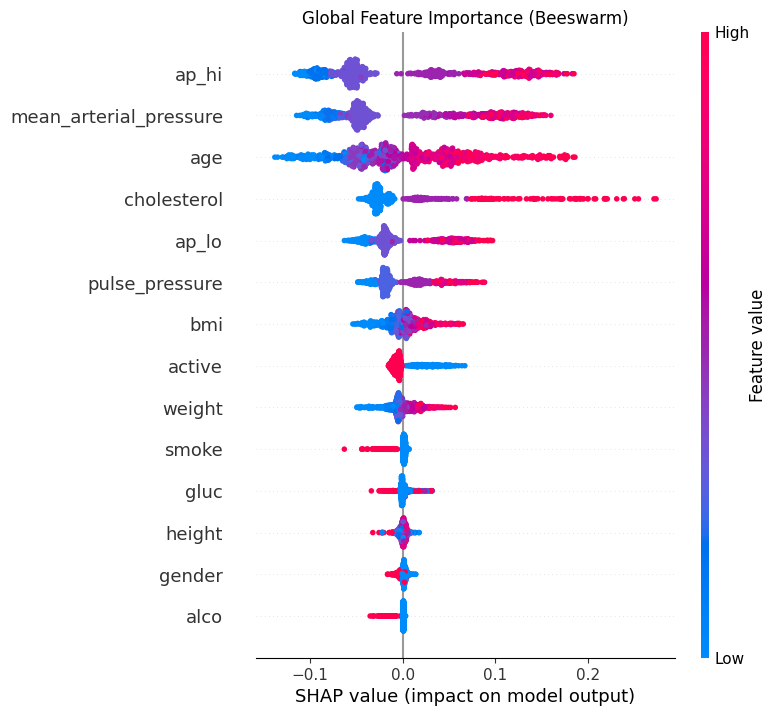

<Figure size 1200x300 with 0 Axes>

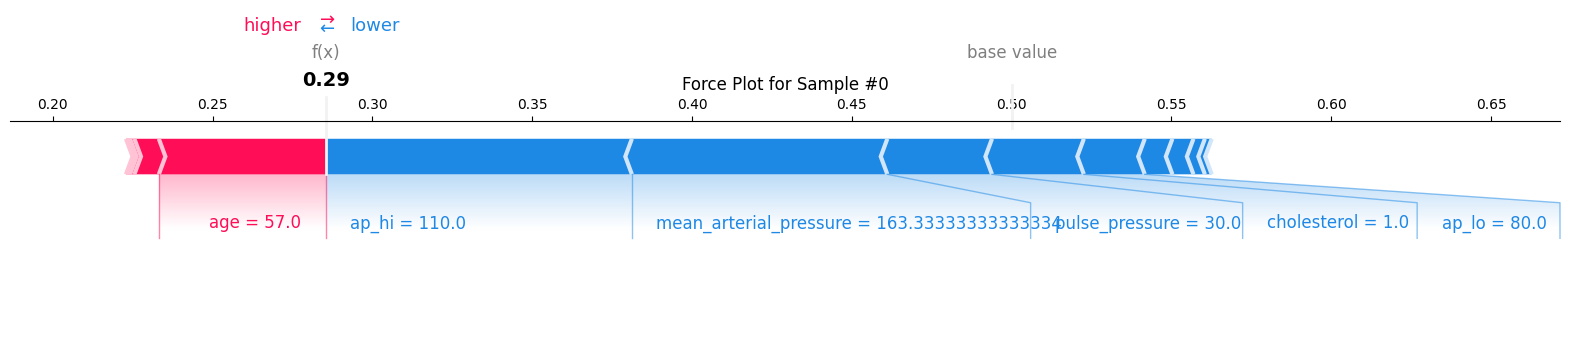

In [31]:
# 1. Setup Explainer
rf_model = final_pipeline_rf.named_steps['model']
explainer = shap.TreeExplainer(rf_model)

# 2. Get SHAP values
shap_values_all = explainer.shap_values(X_fast)
shap_values = shap_values_all[:, :, 1] if len(np.array(shap_values_all).shape) == 3 else shap_values_all

# --- 3. SHAP IMPORTANCE TABLE ---
# Calculates the mean absolute impact of each feature
importance_df = pd.DataFrame({
    'Feature': X_fast.columns,
    'Importance': np.abs(shap_values).mean(0)
}).sort_values(by='Importance', ascending=False)

print("\n--- SHAP Feature Importance Table ---")
print(importance_df.to_string(index=False))

# --- 4. GLOBAL BEESWARM PLOT ---
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_fast, plot_type="dot", show=False)
plt.title("Global Feature Importance (Beeswarm)")
plt.show()

# --- 5. LOCAL FORCE PLOT ---
sample_idx = 0
plt.figure(figsize=(12, 3))
shap.force_plot(
    explainer.expected_value[1],
    shap_values[sample_idx],
    X_fast.iloc[sample_idx],
    matplotlib=True,
    show=False
)
plt.title(f"Force Plot for Sample #{sample_idx}")
plt.show()

LIME ANALYSIS ON V2:
-


--- LIME Feature Importance Table (Sample #0) ---
                       Condition  Weight             Impact
                 ap_hi <= 120.00 -0.1491 Contradicts Cardio
mean_arterial_pressure <= 173.33 -0.1298 Contradicts Cardio
             cholesterol <= 1.00 -0.1252 Contradicts Cardio
                  ap_lo <= 80.00 -0.0543 Contradicts Cardio
         pulse_pressure <= 40.00 -0.0312 Contradicts Cardio
            53.00 < age <= 58.00  0.0232    Supports Cardio
                   smoke <= 0.00  0.0209    Supports Cardio
                 weight <= 65.00 -0.0202 Contradicts Cardio
                    alco <= 0.00  0.0178    Supports Cardio
                height <= 159.00 -0.0114 Contradicts Cardio

--- LIME Visualization for Sample #0 ---
Final Model Prediction: No Cardio


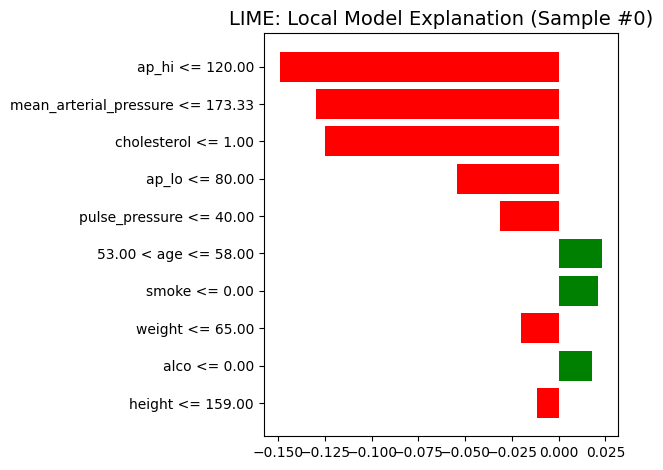

In [53]:
# 1. Setup the LIME Explainer (Using .values to avoid index issues)
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Cardio', 'Cardio'],
    mode='classification'
)

# 2. Pick the sample and convert to .values (Fixes KeyError: 0)
sample_idx = 0
sample_to_explain = X_fast.iloc[sample_idx].values

# 3. Generate Explanation
exp = explainer_lime.explain_instance(
    data_row=sample_to_explain,
    predict_fn=final_pipeline_rf.predict_proba,
    num_features=10
)

# --- 4. NEW: GENERATE LIME DATA TABLE ---
# Extracting the local explanation as a list of tuples
lime_data = exp.as_list()

# Create a DataFrame for the table
lime_table = pd.DataFrame(lime_data, columns=['Condition', 'Weight'])

# Add a column to interpret the impact (Positive weight = Supports the prediction)
# If the prediction is 'Cardio' (1), positive weights pushed it toward that decision.
lime_table['Impact'] = lime_table['Weight'].apply(
    lambda x: 'Supports Cardio' if x > 0 else 'Contradicts Cardio'
)

# Clean up formatting for the display
lime_table['Weight'] = lime_table['Weight'].round(4)

print(f"\n--- LIME Feature Importance Table (Sample #{sample_idx}) ---")
print(lime_table.to_string(index=False))

# --- 5. VISUALIZE ---
print(f"\n--- LIME Visualization for Sample #{sample_idx} ---")
prediction = final_pipeline_rf.predict(X_fast.iloc[[sample_idx]])[0]
print(f"Final Model Prediction: {'Cardio' if prediction == 1 else 'No Cardio'}")

exp.as_pyplot_figure()
plt.title(f"LIME: Local Model Explanation (Sample #{sample_idx})", fontsize=14)
plt.tight_layout()
plt.show()